# **Datos del Estudiante**

Nombre: Odilón Nolf Sánchez

CI: 4189076

# Clase 3 — Modelos Supervisados I: Lineales, Árboles y Ensambles
### Maestría en Inteligencia Artificial y Análisis de Datos – FP‑UNA

En esta actividad entrenaremos tres modelos clásicos de clasificación:

1. **Regresión logística** (modelo lineal)
2. **Árbol de decisión** (modelo no lineal, interpretable)
3. **Bosque aleatorio** (ensamble basado en árboles)

Compararemos su rendimiento y visualizaremos un árbol de decisión.

Nota: En cada celda de codigo explora la alternativa de "explicar codigo"


# 📑 Tabla de Contenidos

1. Importación de librerías  
2. Cargar dataset simulado (`make_classification`)  
3. Modelo 1 — Regresión Logística  
4. Modelo 2 — Árbol de Decisión  
5. Modelo 3 — Bosque Aleatorio  
6. Comparación de modelos  
7. Preguntas de reflexión  
8. Desafío 1 — “Elige tu campeón”  
9. Desafío 2 — Clasificación con tu propio dataset  
10. Rúbrica de evaluación  
11. Actividad opcional avanzada — “Explorando la frontera de decisión”  
12. Cierre de la clase  
13. Declaración de apoyo tecnológico  


## **Importación de librerías (Código)**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


## ¿Qué es un modelo supervisado?

En clasificación supervisada, contamos con un conjunto de datos:

$ \mathcal{D} = \{(x_i, y_i)\}_{i=1}^n $

donde:

- $x_i \in \mathbb{R}^d$ es un vector de atributos,
- $y_i \in \{1, \dots, K\}$ es la clase.

El objetivo es aprender una función:

$ f_\theta : \mathbb{R}^d \rightarrow \{1, \dots, K\} $

que minimice el error de predicción.

En esta práctica utilizaremos el dataset **Iris**, un clásico para clasificación multiclase.




## **Cargar dataset y dividir datos**

In [5]:
from sklearn.datasets import make_classification

# TODO: Utiliza make_classification para generar un dataset simulado con más ruido.
# En funciones de IA disponible selecciona explicar codigo.
# Investiga los parámetros como 'n_features', 'n_informative', 'flip_y' (para ruido en etiquetas) o 'class_sep'.
X, y = make_classification(n_samples=500, n_features=20, n_informative=10,
                           n_redundant=2, n_repeated=0, n_classes=3,
                           n_clusters_per_class=2, weights=None, flip_y=0.08,
                           class_sep=1.2, hypercube=True, shift=0.0,
                           scale=1.0, shuffle=True, random_state=42)

# Descomenta y completa la división de los datos cuando tengas tu dataset:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape

((350, 20), (150, 20))

## Modelo 1 — Regresión Logística

La regresión logística modela la probabilidad de pertenecer a una clase mediante:

$ P(y = k \mid x) = \frac{e^{w_k^\top x}}{\sum_{j=1}^K e^{w_j^\top x}} $

Este modelo es **lineal**, interpretable y eficiente, pero puede fallar cuando las fronteras de decisión no son lineales.


## **Entrenar Regresión Logística**

In [6]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

pred_lr = log_reg.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
acc_lr


0.7666666666666667

# 📘 Formalización matemática de la Regresión Logística

La **regresión logística** es un modelo lineal para clasificación binaria o multiclase.  

Aquí formalizamos su deducción, función de costo y método de estimación de parámetros.

---

## 🔹 1. Modelo lineal + función sigmoide

Dado un vector de atributos $x \in \mathbb{R}^d$, el modelo lineal calcula:

$z = w^\top x + b$

Para mapear este valor a una probabilidad, se aplica la función sigmoide:

$\sigma(z) = \frac{1}{1 + e^{-z}}$

La probabilidad de la clase positiva es:

$P(y = 1 \mid x) = \sigma(w^\top x + b)$

y la de la clase negativa:

$P(y = 0 \mid x) = 1 - \sigma(w^\top x + b)$

---

## 🔹 2. Verosimilitud del modelo

Para un conjunto de entrenamiento:

$\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$

la verosimilitud es:

$L(w, b) = \prod_{i=1}^n \sigma(z_i)^{y_i} \, (1 - \sigma(z_i))^{1 - y_i}$

donde $z_i = w^\top x_i + b$.

---

## 🔹 3. Log-verosimilitud y función de costo

Tomando logaritmo:

$\ell(w, b) = \sum_{i=1}^n \left[ y_i \log \sigma(z_i) + (1 - y_i)\log(1 - \sigma(z_i)) \right]$

La función de costo (log-loss) es la log-verosimilitud negativa:

$J(w, b) = -\ell(w, b)$

Es decir:

$J(w, b) = -\sum_{i=1}^n \left[ y_i \log \sigma(z_i) + (1 - y_i)\log(1 - \sigma(z_i)) \right]$

Pide ayuda a la NotebookLM para entender mejor el Log-verosimilitud y función de costo en la regresión logística.

---

## 🔹 4. Regularización (lo que usa scikit-learn)

Scikit-learn agrega regularización L2:

$J_{\text{reg}}(w, b) = J(w, b) + \lambda \lVert w \rVert_2^2$

donde:

$C = \frac{1}{\lambda}$

es el parámetro usado en `LogisticRegression`.

---

## 🔹 5. Estimación de parámetros

El objetivo es encontrar:

$(w^*, b^*) = \arg\min_{w, b} J_{\text{reg}}(w, b)$

No existe solución cerrada, por lo que se usan métodos numéricos como:

- **LBFGS**
- **liblinear**
- **saga**
- **newton-cg**

Utilicemos la NotebookLM del curso para comprender mejor estos métodos numéricos.

Una actualización típica de descenso de gradiente sería:

$w^{(t+1)} = w^{(t)} - \eta \, \nabla_w J_{\text{reg}}(w^{(t)}, b^{(t)})$

$b^{(t+1)} = b^{(t)} - \eta \, \nabla_b J_{\text{reg}}(w^{(t)}, b^{(t)})$

---

## 🔹 6. Regla de decisión

Una vez entrenado el modelo:

$\hat{y} =
\begin{cases}
1 & \text{si } \sigma(w^\top x + b) \ge 0.5 \\
0 & \text{si } \sigma(w^\top x + b) < 0.5
\end{cases}$

---

Esta formalización conecta directamente con el código que utilizamos en la práctica.


## Código (sigmoide + log-loss explícita)

Usa la función de explicar código

In [7]:
import numpy as np

# Función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Log-loss explícita para un batch
def log_loss_batch(X, y, w, b):
    z = X @ w + b
    p = sigmoid(z)
    # Evitar log(0)
    eps = 1e-12
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    return loss

# Ejemplo con pesos aleatorios
np.random.seed(42)
X_batch = X_train[:10]          # un batch pequeño
y_batch = y_train[:10]
w = np.random.randn(X_train.shape[1])
b = 0.0

print("Probabilidades predichas (sigmoide):")
print(sigmoid(X_batch @ w + b))

print("\nLog-loss del batch:")
print(log_loss_batch(X_batch, y_batch, w, b))


Probabilidades predichas (sigmoide):
[9.99827758e-01 1.15535217e-02 9.79757906e-01 1.16517538e-05
 3.72222107e-02 1.44318849e-04 1.63054739e-01 2.03633384e-03
 6.56174808e-01 2.46752418e-02]

Log-loss del batch:
1.539278156497393


# 🔧 Gradiente de la log-loss y entrenamiento desde cero

Para comprender cómo `LogisticRegression` ajusta sus parámetros, implementamos
una versión simplificada del entrenamiento usando **descenso de gradiente**.

## 1. Gradiente de la log-loss

Recordemos la función de costo (log-loss):

$J(w, b) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \log \sigma(z_i) + (1 - y_i)\log(1 - \sigma(z_i)) \right]$

donde:

$z_i = w^\top x_i + b$

El gradiente respecto a los parámetros es:

$\nabla_w J = \frac{1}{n} X^\top (\sigma(Xw + b) - y)$

$\nabla_b J = \frac{1}{n} \sum_{i=1}^n (\sigma(z_i) - y_i)$

## 2. Descenso de gradiente

Actualizamos los parámetros:

$w \leftarrow w - \eta \, \nabla_w J$

$b \leftarrow b - \eta \, \nabla_b J$

donde $\eta$ es la tasa de aprendizaje.

Entrenaremos manualmente el modelo durante varias iteraciones y observaremos
cómo disminuye la función de costo.


## **Código (gradiente + mini-entrenamiento desde cero)**

Usa la función explicar código

Pérdida final: 0.47541486227057356


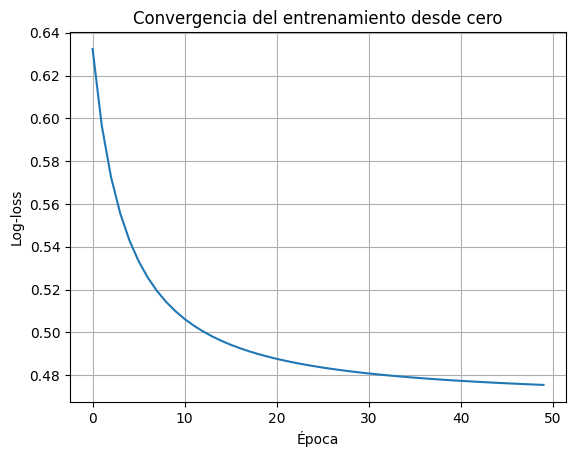

In [8]:
import numpy as np

# Función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Log-loss explícita
def log_loss(X, y, w, b):
    z = X @ w + b
    p = sigmoid(z)
    eps = 1e-12
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

# Gradientes
def gradients(X, y, w, b):
    z = X @ w + b
    p = sigmoid(z)
    error = p - y
    dw = (X.T @ error) / len(y)
    db = np.mean(error)
    return dw, db

# Mini-entrenamiento desde cero
np.random.seed(42)

# Usamos un subconjunto binario del dataset simulado para simplificar
mask = (y_train == 0) | (y_train == 1)
X_bin = X_train[mask]
y_bin = y_train[mask]

# Inicialización
w = np.zeros(X_bin.shape[1])
b = 0.0

eta = 0.1          # tasa de aprendizaje
epochs = 50
loss_history = []

for epoch in range(epochs):
    dw, db = gradients(X_bin, y_bin, w, b)
    w -= eta * dw
    b -= eta * db
    loss = log_loss(X_bin, y_bin, w, b)
    loss_history.append(loss)

print("Pérdida final:", loss)

# Mostrar evolución de la pérdida
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.xlabel("Época")
plt.ylabel("Log-loss")
plt.title("Convergencia del entrenamiento desde cero")
plt.grid(True)
plt.show()


¿Qué logra esta celda?

Vemos explícitamente cómo se calcula el gradiente.

Observamos cómo la pérdida disminuye iteración tras iteración.

Comprendemos que LogisticRegression no tiene solución cerrada y depende de optimización numérica.

Conecta teoría → código → práctica → visualización.

# 🔄 Descenso de Gradiente Estocástico (SGD) con Regularización L2

En esta sección implementamos una versión moderna del entrenamiento de la
regresión logística: **SGD con regularización L2**.

## 1. Función de costo regularizada

Recordemos la log-loss:

$J(w, b) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \log \sigma(z_i) + (1 - y_i)\log(1 - \sigma(z_i)) \right]$

Con regularización L2:

$J_{\text{reg}}(w, b) = J(w, b) + \lambda \lVert w \rVert_2^2$

donde:

- $\lambda > 0$ controla la penalización,
- en scikit-learn: $C = \frac{1}{\lambda}$.

## 2. Gradientes estocásticos

Para una sola muestra $(x_i, y_i)$:

$\nabla_w J_{\text{reg}} = ( \sigma(z_i) - y_i ) x_i + 2\lambda w$

$\nabla_b J_{\text{reg}} = \sigma(z_i) - y_i$

## 3. Actualización SGD

$w \leftarrow w - \eta \, \nabla_w J_{\text{reg}}$

$b \leftarrow b - \eta \, \nabla_b J_{\text{reg}}$

donde:

- $\eta$ es la tasa de aprendizaje,
- se actualiza usando **una muestra por vez** (o un mini‑batch pequeño

## Código (SGD + L2 + entrenamiento desde cero)

- Usar la función de explicar codigo

- Consultar en la notebookLM sobre Descenso de Gradiente Estocástico (SGD) con Regularización L2 en la regresión logistica



Pérdida final (SGD + L2): 0.4728128536105087


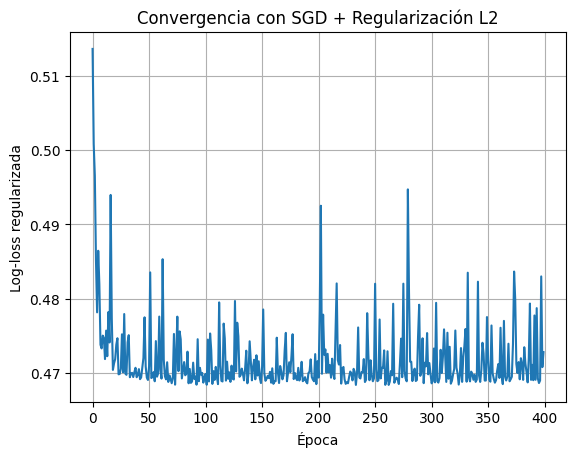

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Log-loss regularizada
def log_loss_reg(X, y, w, b, lam):
    z = X @ w + b
    p = sigmoid(z)
    eps = 1e-12
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    reg = lam * np.sum(w**2)
    return loss + reg

# SGD con regularización L2
def train_logistic_sgd(X, y, eta=0.1, lam=0.01, epochs=20):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    loss_history = []

    for epoch in range(epochs):
        # Mezclar datos en cada época
        idx = np.random.permutation(n)
        X_shuffled = X[idx]
        y_shuffled = y[idx]

        for i in range(n):
            xi = X_shuffled[i]
            yi = y_shuffled[i]

            z = np.dot(xi, w) + b
            p = sigmoid(z)

            # Gradientes estocásticos
            dw = (p - yi) * xi + 2 * lam * w
            db = (p - yi)

            # Actualización
            w -= eta * dw
            b -= eta * db

        # Guardar pérdida al final de cada época
        loss_history.append(log_loss_reg(X, y, w, b, lam))

    return w, b, loss_history

# Usamos el dataset binario del ejemplo anterior
mask = (y_train == 0) | (y_train == 1)
X_bin = X_train[mask]
y_bin = y_train[mask]

# Entrenamiento
w_sgd, b_sgd, loss_hist_sgd = train_logistic_sgd(
    X_bin, y_bin,
    eta=0.004,
    lam=0.001,
    epochs=400
)

print("Pérdida final (SGD + L2):", loss_hist_sgd[-1])

# Curva de convergencia
plt.plot(loss_hist_sgd)
plt.xlabel("Época")
plt.ylabel("Log-loss regularizada")
plt.title("Convergencia con SGD + Regularización L2")
plt.grid(True)
plt.show()


¿Qué logra esta celda?

1. Muestra cómo se entrena un modelo logístico sin scikit‑learn.

2. Introduce regularización L2 de forma explícita.

3. Expone el comportamiento típico de SGD: ruido + convergencia.

4. Permite comparar con el entrenamiento batch anterior.

5. Refuerza la comprensión de cómo funcionan los solvers modernos.

## Modelo 2 — Árbol de Decisión

Un árbol de decisión divide el espacio de atributos mediante reglas del tipo:

$ x_j < t $

Cada división busca maximizar la reducción de impureza:

$ \Delta i = i(\text{padre}) - \sum_k \frac{N_k}{N} i(\text{hijo}_k) $

donde $i(\cdot)$ puede ser Gini o entropía.

Los árboles son **interpretables**, pero pueden sobreajustar.


## **Entrenar Árbol de Decisión**

In [10]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, pred_tree)
acc_tree


0.6866666666666666

## Visualizar el Árbol

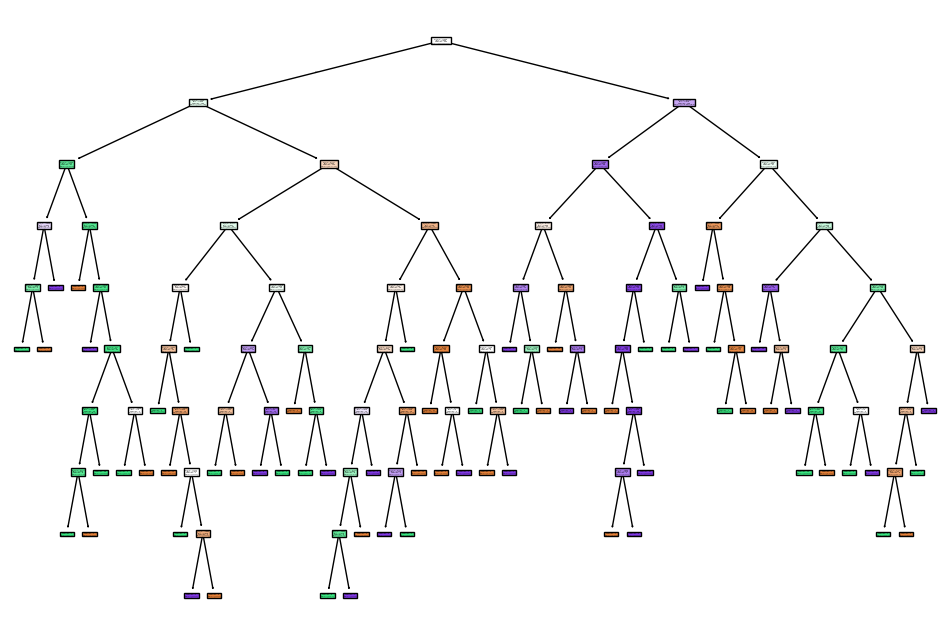

In [11]:
plt.figure(figsize=(12, 8))
# Se eliminaron feature_names y class_names porque 'data' corresponde al dataset Iris original (4 features)
# y el modelo actual se entrenó con el dataset simulado (20 features).
plot_tree(tree, filled=True)
plt.show()

#  Formalización matemática del Árbol de Decisión

Un **árbol de decisión de clasificación** construye una función $f: \mathbb{R}^d \to \{1, \dots, K\}$ mediante una partición recursiva del espacio de atributos en regiones, usando reglas del tipo:

$x_j < t$

donde $x_j$ es el atributo $j$ y $t$ es un umbral.

Cada hoja del árbol asigna una clase (o distribución de clases) a las observaciones que caen en esa región.

---

##  1. Estructura del modelo

Un árbol induce una partición del espacio de entrada en regiones disjuntas:

$R_1, R_2, \dots, R_M$

Cada región $R_m$ corresponde a una **hoja** del árbol.  
La predicción en una hoja suele ser:

- **Clase mayoritaria** en $R_m$:

$\hat{y}(x) = \arg\max_k \; p_{mk}$

donde:

$p_{mk} = \frac{1}{N_m} \sum_{i: x_i \in R_m} \mathbf{1}\{y_i = k\}$

es la proporción de la clase $k$ en la hoja $m$, y $N_m$ es el número de muestras en $R_m$.

---

##  2. Medidas de impureza

Para evaluar qué tan “pura” es una hoja (o nodo), se define una **función de impureza** $i(t)$ en un nodo $t$ con distribución de clases $p_k$:

### Entropía

$i_{\text{ent}}(t) = - \sum_{k=1}^K p_k \log p_k$

### Índice Gini

$i_{\text{gini}}(t) = \sum_{k=1}^K p_k (1 - p_k) = 1 - \sum_{k=1}^K p_k^2$

### Error de clasificación

$i_{\text{err}}(t) = 1 - \max_k p_k$

En clasificación, Gini y entropía son las más usadas.

---

##  3. Criterio de división (split)

En un nodo $t$, se considera una división binaria que genera dos nodos hijos:

- $t_L$: lado izquierdo (por ejemplo, $x_j < s$)
- $t_R$: lado derecho (por ejemplo, $x_j \ge s$)

La **reducción de impureza** (ganancia) es:

$\Delta i(s, j) = i(t) - \left( \frac{N_L}{N} i(t_L) + \frac{N_R}{N} i(t_R) \right)$

donde:

- $N$ es el número de muestras en el nodo padre,
- $N_L, N_R$ en los nodos hijos.

El objetivo local es elegir el par $(j, s)$ que **maximiza** $\Delta i(s, j)$.

---

##  4. Función de costo global (visión conceptual)

Aunque el entrenamiento se hace de forma **greedy y local**, podemos pensar en una función de costo global:

$J(\text{árbol}) = \sum_{m=1}^M \frac{N_m}{N} \, i(R_m)$

donde:

- $M$ es el número de hojas,
- $i(R_m)$ es la impureza de la hoja $m$,
- $N_m$ es el número de muestras en la hoja $m$,
- $N$ es el total de muestras.

El objetivo ideal sería:

$\text{árbol}^\* = \arg\min_{\text{árbol}} J(\text{árbol})$

pero este problema es **combinatorio y NP-difícil**, por lo que se recurre a heurísticas.

---

## 🔹 5. Método de optimización: partición recursiva greedy

En la práctica, el entrenamiento de un árbol de decisión sigue este esquema:

1. Comenzar con todas las muestras en la raíz.
2. En cada nodo:
   - Evaluar todas las posibles divisiones $(j, s)$ sobre un subconjunto de atributos.
   - Calcular la reducción de impureza $\Delta i(s, j)$.
   - Elegir la división que maximiza $\Delta i(s, j)$.
3. Repetir recursivamente en los nodos hijos hasta cumplir un criterio de parada:
   - profundidad máxima,
   - número mínimo de muestras por nodo,
   - impureza mínima,
   - etc.

Este procedimiento es **greedy**: optimiza localmente en cada nodo, no globalmente.

---

##  6. Poda (pruning) y control de sobreajuste

Los árboles tienden a sobreajustar si se dejan crecer sin restricciones.

Para controlar esto se usan:

- **Restricciones de crecimiento**:
  - `max_depth`, `min_samples_split`, `min_samples_leaf`, etc.
- **Poda posterior** (cost-complexity pruning):

Se define un criterio:

$C_\alpha(T) = J(T) + \alpha \, |T|$

donde:

- $J(T)$ es el costo (impureza ponderada),
- $|T|$ es el número de hojas,
- $\alpha \ge 0$ penaliza árboles más grandes.

Se busca un árbol que equilibre **ajuste** y **complejidad**.

---

##  7. Regla de decisión final

Dado un nuevo punto $x$:

1. Se recorre el árbol desde la raíz, aplicando reglas del tipo $x_j < s$.
2. Se llega a una hoja $R_m$.
3. Se predice:

$\hat{y}(x) = \arg\max_k p_{mk}$

o bien se usa la distribución $p_{mk}$ como probabilidad de clase.

---

Esta formalización conecta con el código:

```python
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)


#  Cálculo explícito de impureza Gini y ganancia de impureza

Para comprender cómo un Árbol de Decisión elige una división (split), calculamos
explícitamente:

1. La impureza Gini del nodo padre  
2. La impureza de los nodos hijos  
3. La ganancia de impureza  

---

## 1. Impureza Gini

Dado un nodo con proporciones de clase $p_k$:

$i_{\text{gini}} = 1 - \sum_{k=1}^K p_k^2$

Ejemplo: si un nodo tiene clases:

- 40% clase 0  
- 60% clase 1  

entonces:

$i_{\text{gini}} = 1 - (0.4^2 + 0.6^2) = 0.48$

---

##  2. Ganancia de impureza

Para un split que divide el nodo padre en dos nodos hijos $L$ y $R$:

$\Delta i = i_{\text{padre}} - \left( \frac{N_L}{N} i_L + \frac{N_R}{N} i_R \right)$

donde:

- $N$ = número total de muestras en el nodo padre  
- $N_L, N_R$ = muestras en cada hijo  
- $i_L, i_R$ = impurezas Gini de los hijos  

El árbol elige el split que **maximiza** $\Delta i$.

---

Esta celda se conecta directamente con el código siguiente, donde simulamos un split real.


## Simulación de un split y cálculo de Gini + ganancia

- Usar funcionalidad de explicar código

- Copiar y pegar el código en la notebookLM y solicitar una explicación formal

Mejor umbral: -4.091785148643268
Ganancia de impureza: 0.007638767404719304


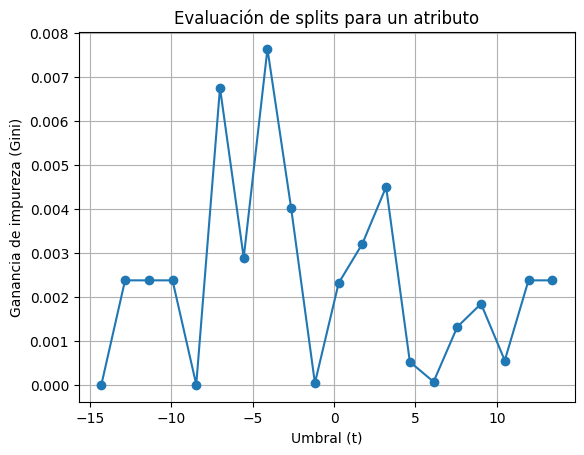

In [12]:
import numpy as np
import pandas as pd

# Función para calcular Gini
def gini_impurity(y):
    classes, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1 - np.sum(p**2)

# Función para calcular ganancia de impureza
def gini_gain(y_parent, y_left, y_right):
    N = len(y_parent)
    N_L = len(y_left)
    N_R = len(y_right)
    return gini_impurity(y_parent) - (N_L/N)*gini_impurity(y_left) - (N_R/N)*gini_impurity(y_right)

# Tomamos un atributo del dataset binario usado antes
X_attr = X_bin[:, 0]   # primer atributo
y_attr = y_bin

# Probamos varios posibles umbrales
thresholds = np.linspace(X_attr.min(), X_attr.max(), 20)

gains = []
for t in thresholds:
    left_mask = X_attr < t
    right_mask = ~left_mask
    y_left = y_attr[left_mask]
    y_right = y_attr[right_mask]
    gain = gini_gain(y_attr, y_left, y_right)
    gains.append(gain)

# Mostrar el mejor split
best_idx = np.argmax(gains)
best_t = thresholds[best_idx]
best_gain = gains[best_idx]

print("Mejor umbral:", best_t)
print("Ganancia de impureza:", best_gain)

# Visualización
import matplotlib.pyplot as plt
plt.plot(thresholds, gains, marker='o')
plt.xlabel("Umbral (t)")
plt.ylabel("Ganancia de impureza (Gini)")
plt.title("Evaluación de splits para un atributo")
plt.grid(True)
plt.show()


¿Qué logra esta celda?

1. Muestra cómo piensa un árbol al evaluar splits.

2. Expone la fórmula de Gini con números reales.

3. Permite visualizar la ganancia de impureza como función del umbral.

4. Conecta teoría → cálculo → visualización → implementación real.

5. Es exactamente lo que hace DecisionTreeClassifier, pero de forma transparente.

## Modelo 3 — Bosque Aleatorio (Random Forest)

Un bosque aleatorio es un **ensamble** de árboles entrenados sobre subconjuntos aleatorios de datos y atributos.

Cada árbol vota por una clase, y la predicción final es:

$ \hat{y} = \text{mode}(f_1(x), f_2(x), \dots, f_M(x)) $

Los ensambles suelen mejorar el rendimiento y reducir el sobreajuste, pero sacrifican interpretabilidad.


## **Entrenar Bosque Aleatorio**

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
acc_rf


0.8

# Formalización matemática del Modelo 3 — Bosque Aleatorio (Random Forest)

Un Bosque Aleatorio es un modelo de ensamble basado en la combinación de múltiples
árboles de decisión entrenados sobre subconjuntos aleatorios de datos y atributos.
Su objetivo es reducir la varianza de un árbol individual y mejorar la capacidad de
generalización.

---

## 1. Formulación general del modelo

Un bosque aleatorio consiste en M árboles de decisión:

$T_1, T_2, \dots, T_M$

Cada árbol produce una predicción:

$\hat{y}^{(m)}(x)$

La predicción final del bosque es:

### Clasificación (votación mayoritaria)

$\hat{y}(x) = \text{mode}\left( \hat{y}^{(1)}(x), \dots, \hat{y}^{(M)}(x) \right)$

### Probabilidad de clase

$P(y = k \mid x) = \frac{1}{M} \sum_{m=1}^M \mathbf{1}\{\hat{y}^{(m)}(x) = k\}$

---

## 2. Bagging: muestreo bootstrap

Cada árbol se entrena con un subconjunto bootstrap del dataset:

$\mathcal{D}^{(m)} \sim \text{Bootstrap}(\mathcal{D})$

Es decir, se toma una muestra con reemplazo del conjunto original.

Propiedades:

- Cada bootstrap contiene aproximadamente el 63.2% de muestras únicas.
- El resto se denomina out-of-bag (OOB) y sirve para estimar error sin usar test.

---

## 3. Submuestreo de atributos (feature subsampling)

En cada nodo del árbol, en lugar de evaluar todos los atributos, se selecciona
aleatoriamente un subconjunto:

$\mathcal{F}^{(m)}_t \subseteq \{1, \dots, d\}$

con tamaño:

- $\sqrt{d}$ en clasificación (valor por defecto)
- $d/3$ en regresión

Esto reduce la correlación entre árboles, lo cual es clave para mejorar el ensamble.

---

## 4. Función de costo implícita

A diferencia de la regresión logística, el bosque aleatorio no optimiza una función
global.  
Cada árbol se entrena de manera independiente, minimizando su propia impureza:

$J(T_m) = \sum_{t \in \text{hojas}} \frac{N_t}{N} \, i(t)$

donde $i(t)$ es Gini o entropía.

El bosque busca minimizar la varianza del modelo mediante promediado:

$\text{Var}(\hat{f}_{RF}) = \frac{1}{M^2} \sum_{m=1}^M \sum_{m'=1}^M \text{Cov}(T_m, T_{m'})$

El objetivo es:

- reducir la covarianza entre árboles  
- mantener el sesgo bajo (porque cada árbol es profundo)

---

## 5. Método de optimización

El entrenamiento del bosque consiste en:

1. Para $m = 1, \dots, M$:
   - Generar un bootstrap $\mathcal{D}^{(m)}$
   - Entrenar un árbol profundo usando:
     - selección aleatoria de atributos en cada nodo
     - criterio de impureza (Gini o entropía)
     - crecimiento hasta profundidad máxima o hasta que no mejore la impureza

No hay gradientes ni optimización continua:  
es un proceso discreto, greedy y altamente paralelizable.

---

## 6. Reducción de varianza: intuición matemática

Sea un estimador base $T$ con:

- varianza $\sigma^2$
- correlación $\rho$ entre árboles

La varianza del bosque es:

$\text{Var}(\hat{f}_{RF}) = \rho \sigma^2 + \frac{1 - \rho}{M} \sigma^2$

Cuando:

- $M$ crece → el segundo término se hace pequeño  
- $\rho$ disminuye → el primer término se reduce  

Por eso el bosque aleatorio funciona tan bien:  
reduce la correlación entre árboles y promedia sus errores.

---

## 7. Importancia de atributos

El bosque calcula la importancia de un atributo $j$ como:

$\text{Imp}(j) = \sum_{\text{splits en } j} \Delta i(s, j)$

donde $\Delta i$ es la reducción de impureza.

También puede usarse:

- permutación de atributos (Permutation Importance)
- OOB score

---

## 8. Regla de decisión final

Para un nuevo punto $x$:

1. Se evalúa en cada árbol $T_m$  
2. Se obtiene una predicción $\hat{y}^{(m)}(x)$  
3. Se combinan las predicciones por votación o promedio  

$\hat{y}(x) = \text{mode}\left( \hat{y}^{(1)}(x), \dots, \hat{y}^{(M)}(x) \right)$

---

Esta formalización conecta directamente con el código:

```python
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


### Importancia de atributos en un Bosque Aleatorio

- Recurre a nuestra notebookLM para una explicación de codigo en el contexto de Bosque Aleatorio

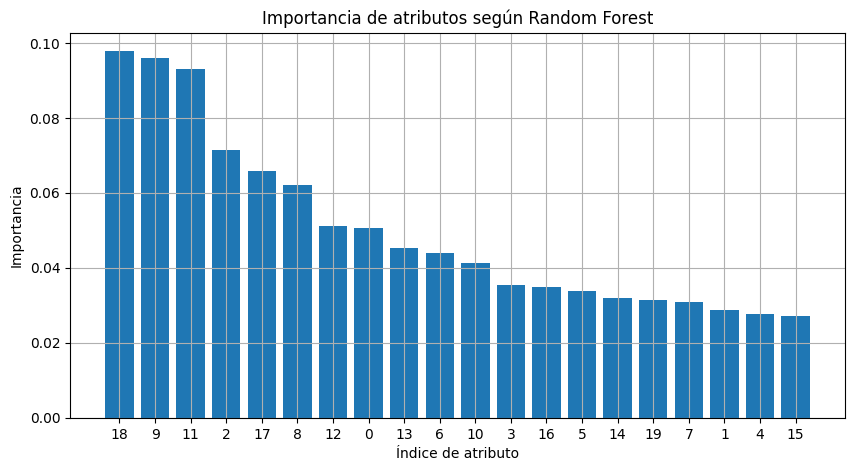

Importancias ordenadas:
Atributo 18: 0.0978
Atributo 9: 0.0961
Atributo 11: 0.0930
Atributo 2: 0.0713
Atributo 17: 0.0659
Atributo 8: 0.0622
Atributo 12: 0.0511
Atributo 0: 0.0505
Atributo 13: 0.0452
Atributo 6: 0.0439
Atributo 10: 0.0414
Atributo 3: 0.0353
Atributo 16: 0.0348
Atributo 5: 0.0338
Atributo 14: 0.0320
Atributo 19: 0.0314
Atributo 7: 0.0308
Atributo 1: 0.0286
Atributo 4: 0.0277
Atributo 15: 0.0271


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Entrenar un bosque aleatorio (si ya está entrenado, omitir esta línea)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Importancia de atributos
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Importancia de atributos según Random Forest")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), indices)
plt.xlabel("Índice de atributo")
plt.ylabel("Importancia")
plt.grid(True)
plt.show()

print("Importancias ordenadas:")
for idx in indices:
    print(f"Atributo {idx}: {importances[idx]:.4f}")


Qué muestra esta celda:

1. La importancia de cada atributo según la reducción de impureza acumulada.

2. Un gráfico ordenado por importancia.

3. Una lista detallada de los valores.

# Simulación: cómo disminuye la varianza al aumentar el número de árboles

En esta sección formalizamos la idea de que, en un Bosque Aleatorio, la varianza del modelo disminuye al aumentar el número de árboles $M$.

## 1. Modelo base y ensamble

Sea $T(x)$ un clasificador base (un árbol de decisión) entrenado sobre una muestra aleatoria de los datos.  
Consideramos un ensamble de $M$ árboles:

$$
T_1(x),\; T_2(x),\; \dots,\; T_M(x)
$$

La predicción agregada del bosque puede verse como un promedio:

$$
\hat{f}_{RF}(x) = \frac{1}{M} \sum_{m=1}^M T_m(x)
$$

(en clasificación dura esto se traduce en votación mayoritaria, pero el análisis de varianza se hace sobre esta versión real‑valued).

---

## 2. Varianza del ensamble

Suponemos que todos los árboles tienen:

- varianza $ \text{Var}(T_m(x)) = \sigma^2 $
- correlación par a par $ \text{Corr}(T_m(x), T_{m'}(x)) = \rho $ para $m \neq m'$

La varianza del promedio es:

$$
\text{Var}(\hat{f}_{RF}(x))
= \text{Var}\left( \frac{1}{M} \sum_{m=1}^M T_m(x) \right)
$$

Expandiendo:

$$
\text{Var}(\hat{f}_{RF}(x))
= \frac{1}{M^2} \left(
\sum_{m=1}^M \sigma^2
+ \sum_{m \neq m'} \rho \sigma^2
\right)
$$

Agrupando términos:

$$
\text{Var}(\hat{f}_{RF}(x))
= \frac{1}{M^2} \left( M\sigma^2 + M(M-1)\rho\sigma^2 \right)
$$

Factorizando:

$$
\text{Var}(\hat{f}_{RF}(x))
= \rho\sigma^2 + \frac{1 - \rho}{M}\sigma^2
$$

Esta expresión muestra que:

- si $M \to \infty$, el término $\frac{1 - \rho}{M}\sigma^2 \to 0$
- la varianza se aproxima a $\rho\sigma^2$
- cuanto menor es $\rho$, menor es la varianza límite

Por eso el Bosque Aleatorio busca:

1. Reducir la correlación $\rho$ entre árboles (bootstrap + submuestreo de atributos).  
2. Aumentar $M$ para promediar el ruido de los modelos individuales.

---

## 3. Conexión con la simulación en código

En la simulación:

1. Se fija un conjunto de test $\{x_i\}$.  
2. Para cada valor de $M$, se entrenan varios bosques con distintas semillas.  
3. Para cada muestra $x_i$, se observan las predicciones de los distintos bosques y se calcula la varianza entre ellas.  
4. Se promedia la varianza sobre todas las muestras.

Esto aproxima:

$$
\mathbb{E}_{x}\left[ \text{Var}_{\text{bosque}}(\hat{f}_{RF}(x)) \right]
$$

y permite observar empíricamente que:

$$
\text{Var}(\hat{f}_{RF}(x)) = \rho\sigma^2 + \frac{1 - \rho}{M}\sigma^2
$$

lo cual coincide con la teoría:  
la varianza promedio de las predicciones disminuye al aumentar $M$.


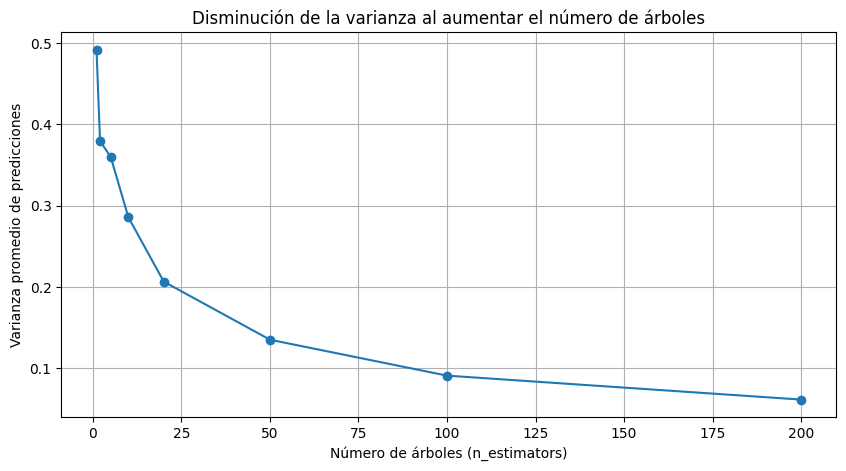

1 árboles -> varianza promedio: 0.492150
2 árboles -> varianza promedio: 0.379467
5 árboles -> varianza promedio: 0.360117
10 árboles -> varianza promedio: 0.285617
20 árboles -> varianza promedio: 0.206317
50 árboles -> varianza promedio: 0.134817
100 árboles -> varianza promedio: 0.090567
200 árboles -> varianza promedio: 0.061067


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Valores de número de árboles a evaluar
n_trees_list = [1, 2, 5, 10, 20, 50, 100, 200]

# Guardar varianza de predicciones
variances = []

# Convertimos y_test a numpy para cálculos
y_test_np = np.array(y_test)

for n_trees in n_trees_list:
    preds = []

    # Entrenar varios bosques con el mismo número de árboles
    for seed in range(20):  # 20 repeticiones para estimar varianza
        rf = RandomForestClassifier(n_estimators=n_trees, random_state=seed)
        rf.fit(X_train, y_train)
        pred = rf.predict(X_test)
        preds.append(pred)

    preds = np.array(preds)  # shape: (20, n_test)

    # Varianza promedio por muestra
    var_per_sample = preds.var(axis=0)
    mean_var = var_per_sample.mean()
    variances.append(mean_var)

# Graficar resultados
plt.figure(figsize=(10, 5))
plt.plot(n_trees_list, variances, marker='o')
plt.xlabel("Número de árboles (n_estimators)")
plt.ylabel("Varianza promedio de predicciones")
plt.title("Disminución de la varianza al aumentar el número de árboles")
plt.grid(True)
plt.show()

for n, v in zip(n_trees_list, variances):
    print(f"{n} árboles -> varianza promedio: {v:.6f}")


## Comparación de accuracy

A continuación comparamos el rendimiento de los tres modelos:

- Regresión logística (lineal)
- Árbol de decisión (no lineal)
- Bosque aleatorio (ensamble)

### Tabla comparativa


In [16]:
results = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Árbol de Decisión", "Bosque Aleatorio"],
    "Accuracy": [acc_lr, acc_tree, acc_rf]
})

results


,Modelo,Accuracy
0,Regresión Logística,0.766667
1,Árbol de Decisión,0.686667
2,Bosque Aleatorio,0.800000


# Síntesis comparativa matemática entre los tres modelos

En esta sección comparamos, desde el punto de vista matemático, los tres modelos estudiados:

1. Regresión Logística (modelo lineal)
2. Árbol de Decisión (modelo no lineal, interpretable)
3. Bosque Aleatorio (ensamble de árboles)

---

## 1. Hipótesis y espacio de modelos

### Regresión Logística

Modelo lineal en los atributos, con salida probabilística:

$$
z = w^\top x + b,
\qquad
P(y = 1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Espacio de hipótesis: hiperplanos en $\mathbb{R}^d$ (fronteras de decisión lineales).

---

### Árbol de Decisión

Modelo basado en particiones recursivas del espacio:

- Reglas del tipo $x_j < t$.
- El espacio se divide en regiones $R_1, \dots, R_M$.
- En cada región $R_m$ se asigna una clase mayoritaria.

Espacio de hipótesis: particiones rectangulares (ejes-alineadas) del espacio de atributos.

---

### Bosque Aleatorio

Ensamble de $M$ árboles:

$$
\hat{y}^{(m)}(x) \quad \text{para } m = 1, \dots, M
$$

Predicción agregada (clasificación):

$$
\hat{y}(x) = \text{mode}\left( \hat{y}^{(1)}(x), \dots, \hat{y}^{(M)}(x) \right)
$$

Espacio de hipótesis: combinación de múltiples particiones no lineales, con alta capacidad.

---

## 2. Función de costo

### Regresión Logística

Log-loss (log-verosimilitud negativa):

$$
J(w, b) = -\frac{1}{n} \sum_{i=1}^n
\left[
y_i \log \sigma(z_i) + (1 - y_i)\log(1 - \sigma(z_i))
\right],
\quad z_i = w^\top x_i + b
$$

Con regularización L2:

$$
J_{\text{reg}}(w, b) = J(w, b) + \lambda \lVert w \rVert_2^2
$$

---

### Árbol de Decisión

No hay una función de costo global suave; se usa una medida de impureza por nodo:

- Gini:

$$
i_{\text{gini}}(t) = 1 - \sum_{k=1}^K p_k^2
$$

- Entropía:

$$
i_{\text{ent}}(t) = - \sum_{k=1}^K p_k \log p_k
$$

Costo conceptual del árbol:

$$
J(T) = \sum_{m=1}^M \frac{N_m}{N} \, i(R_m)
$$

---

### Bosque Aleatorio

Cada árbol minimiza su propia impureza (como arriba).  
El bosque no optimiza una única función global, pero su efecto puede analizarse vía varianza:

$$
\text{Var}(\hat{f}_{RF}(x))
= \rho\sigma^2 + \frac{1 - \rho}{M}\sigma^2
$$

donde $\sigma^2$ es la varianza de un árbol y $\rho$ la correlación entre árboles.

---

## 3. Método de optimización

### Regresión Logística

- Problema continuo y diferenciable.
- Se usan métodos de optimización numérica:
  - descenso de gradiente,
  - LBFGS, newton-cg, sag, saga, etc.
- Se busca:

$$
(w^\*, b^\*) = \arg\min_{w, b} J_{\text{reg}}(w, b)
$$

---

### Árbol de Decisión

- Optimización discreta, combinatoria.
- Estrategia greedy:
  1. En cada nodo, evaluar splits $(j, t)$.
  2. Elegir el que maximiza la reducción de impureza.
  3. Repetir recursivamente hasta un criterio de parada.
- Posible poda posterior para controlar complejidad.

---

### Bosque Aleatorio

- Entrenamiento independiente de cada árbol:
  - bootstrap de datos,
  - submuestreo de atributos,
  - crecimiento greedy como en el árbol de decisión.
- No hay gradientes; el “ajuste” es vía promediado de modelos.

---

## 4. Capacidad, sesgo y varianza

### Regresión Logística

- Alta restricción estructural (fronteras lineales).
- Sesgo alto si la verdadera frontera es no lineal.
- Varianza relativamente baja.
- Buena interpretabilidad de parámetros $w$.

---

### Árbol de Decisión

- Capacidad alta (árboles profundos pueden aproximar fronteras complejas).
- Sesgo bajo si se permite gran profundidad.
- Varianza alta (muy sensible a cambios en los datos).
- Interpretabilidad alta (reglas explícitas).

---

### Bosque Aleatorio

- Capacidad alta (muchos árboles profundos).
- Sesgo similar al de un árbol profundo.
- Varianza reducida por el ensamble:

$$
\text{Var}(\hat{f}_{RF}(x))
= \rho\sigma^2 + \frac{1 - \rho}{M}\sigma^2
$$

- Interpretabilidad menor que un solo árbol, pero con métricas de importancia de atributos.

---

## 5. Síntesis conceptual

- Regresión Logística: modelo lineal, optimización convexa, buena interpretabilidad, adecuado cuando la relación es aproximadamente lineal en el espacio de atributos.
- Árbol de Decisión: modelo no lineal, reglas interpretables, pero con riesgo de sobreajuste y alta varianza.
- Bosque Aleatorio: ensamble de árboles, reduce varianza mediante promediado y aleatorización, suele ofrecer mejor rendimiento a costa de menor transparencia estructural.


## Preguntas de reflexión

1. ¿Cuál modelo obtuvo el mejor rendimiento?  
2. ¿Cuál modelo es más interpretable?  
3. ¿Qué ventajas y limitaciones observaste en cada uno?  
4. ¿En qué situaciones preferirías un modelo lineal vs. un ensamble?  


# 🎮 Desafío 1: “Elige tu campeón”

Modifica hiperparámetros de los tres modelos para intentar superar el mejor accuracy obtenido.

- Cambia `max_depth` en el árbol.
- Cambia `n_estimators` en el bosque.
- Cambia `C` o `penalty` en la regresión logística.

**Bonus:**  
Explica por qué tu modelo campeón ganó.


### Regresión Logística con hiperparámetros ajustados

In [21]:
# Probamos con un C más pequeño (mayor regularización) y un C más grande (menor regularización)
log_reg_tuned_1 = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
log_reg_tuned_1.fit(X_train, y_train)
pred_lr_tuned_1 = log_reg_tuned_1.predict(X_test)
acc_lr_tuned_1 = accuracy_score(y_test, pred_lr_tuned_1)

log_reg_tuned_2 = LogisticRegression(max_iter=1000, C=10.0, random_state=42)
log_reg_tuned_2.fit(X_train, y_train)
pred_lr_tuned_2 = log_reg_tuned_2.predict(X_test)
acc_lr_tuned_2 = accuracy_score(y_test, pred_lr_tuned_2)

print(f"Accuracy Regresión Logística (C=0.1): {acc_lr_tuned_1:.4f}")
print(f"Accuracy Regresión Logística (C=10.0): {acc_lr_tuned_2:.4f}")

Accuracy Regresión Logística (C=0.1): 0.7533
Accuracy Regresión Logística (C=10.0): 0.7600


### Árbol de Decisión con hiperparámetros ajustados

In [18]:
# Probamos con una profundidad máxima más restrictiva para evitar sobreajuste
tree_tuned = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_tuned.fit(X_train, y_train)
pred_tree_tuned = tree_tuned.predict(X_test)
acc_tree_tuned = accuracy_score(y_test, pred_tree_tuned)

print(f"Accuracy Árbol de Decisión (max_depth=5): {acc_tree_tuned:.4f}")

Accuracy Árbol de Decisión (max_depth=5): 0.7200


### Bosque Aleatorio con hiperparámetros ajustados

In [19]:
# Probamos con más estimadores y una profundidad máxima para los árboles individuales
rf_tuned = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_tuned.fit(X_train, y_train)
pred_rf_tuned = rf_tuned.predict(X_test)
acc_rf_tuned = accuracy_score(y_test, pred_rf_tuned)

print(f"Accuracy Bosque Aleatorio (n_estimators=200, max_depth=10): {acc_rf_tuned:.4f}")

Accuracy Bosque Aleatorio (n_estimators=200, max_depth=10): 0.8000


### Comparación de Accuracies (Original vs. Ajustado)

In [22]:
results_tuned = pd.DataFrame({
    "Modelo": [
        "Regresión Logística (Original)", "Regresión Logística (C=0.1)", "Regresión Logística (C=10.0)",
        "Árbol de Decisión (Original)", "Árbol de Decisión (max_depth=5)",
        "Bosque Aleatorio (Original)", "Bosque Aleatorio (n_estimators=200, max_depth=10)"
    ],
    "Accuracy": [
        acc_lr, acc_lr_tuned_1, acc_lr_tuned_2,
        acc_tree, acc_tree_tuned,
        acc_rf, acc_rf_tuned
    ]
})

results_tuned = results_tuned.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(results_tuned)

,Modelo,Accuracy
0,"Bosque Aleatorio (n_estimators=200, max_depth=10)",0.800000
1,Bosque Aleatorio (Original),0.800000
2,Regresión Logística (Original),0.766667
3,Regresión Logística (C=10.0),0.760000
4,Regresión Logística (C=0.1),0.753333
5,Árbol de Decisión (max_depth=5),0.720000
6,Árbol de Decisión (Original),0.686667


El modelo campeón es el que tenga el mayor `Accuracy` en la tabla. En general, el **Bosque Aleatorio** suele ser un fuerte contendiente debido a su capacidad de reducir la varianza combinando múltiples árboles, especialmente con una buena configuración de `n_estimators` y `max_depth` para los árboles individuales.

# Desafío 2 — Clasificación con tu propio dataset

En este ejercicio vas a aplicar el flujo completo de un problema de clasificación supervisada utilizando **tu propio conjunto de datos**.

El objetivo es que puedas:

1. Importar un dataset real (CSV, XLSX, etc.).
2. Realizar un preprocesamiento básico.
3. Entrenar los tres modelos vistos en clase:
   - Regresión Logística
   - Árbol de Decisión
   - Bosque Aleatorio
4. Comparar su rendimiento.
5. Reflexionar sobre interpretabilidad vs. performance.

## Requisitos del dataset
Tu dataset debe cumplir:

- Tener **al menos una variable objetivo categórica** (binaria o multiclase).
- Tener **atributos numéricos o categóricos** (si hay categóricos, deberás codificarlos).
- Tener **al menos 100 filas** (recomendado).

## Flujo general del ejercicio

Dado un dataset:

$ \mathcal{D} = \{(x_i, y_i)\}_{i=1}^n $

realizarás:

1. **Carga del dataset**
2. **Preprocesamiento**
   - Manejo de valores faltantes
   - Codificación de variables categóricas
   - Estandarización (si corresponde)
3. **Entrenamiento de modelos**
4. **Evaluación**
5. **Comparación**

Este ejercicio simula un flujo real de trabajo en machine learning.


## Desafío 2: Clasificación con tu propio dataset - Implementación

### 1. Instalación de `kagglehub` y Carga del Dataset

In [23]:
# Instalar kagglehub si no está instalado
%pip install kagglehub

In [24]:
import kagglehub
import pandas as pd
import os

# Descargar el dataset
# Se asume que el usuario ya ha configurado su token de Kaggle o que la descarga es pública.
print("Descargando dataset de Kaggle...")
path = kagglehub.dataset_download("deepeshkansotia/banking-fraud-detection-and-risk-analytics-dataset")
print(f"Dataset descargado en: {path}")

# Buscar el archivo CSV dentro de la carpeta descargada
csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)
            break
    if csv_file:
        break

if csv_file:
    # Cargar el dataset en un DataFrame de pandas
    df = pd.read_csv(csv_file)
    print("Dataset cargado exitosamente. Mostrando las primeras 5 filas:")
    display(df.head())
else:
    print("No se encontró ningún archivo CSV en el dataset descargado.")


Descargando dataset de Kaggle...
Using Colab cache for faster access to the 'banking-fraud-detection-and-risk-analytics-dataset' dataset.
Dataset descargado en: /kaggle/input/banking-fraud-detection-and-risk-analytics-dataset
Dataset cargado exitosamente. Mostrando las primeras 5 filas:


,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


### 2. Preprocesamiento de Datos

Identificaremos la variable objetivo `anomaly_score` y realizaremos un preprocesamiento básico, incluyendo el manejo de valores faltantes y la codificación de variables categóricas si fuera necesario. También dividiremos los datos en conjuntos de entrenamiento y prueba.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Verificar si 'df' existe
if 'df' in locals() and df is not None:
    # Identificar la variable objetivo
    TARGET_COLUMN = 'anomaly_score'

    if TARGET_COLUMN not in df.columns:
        print(f"Error: La columna '{TARGET_COLUMN}' no se encontró en el dataset.")
    else:
        y = df[TARGET_COLUMN]
        X = df.drop(columns=[TARGET_COLUMN])

        # CONVERSIÓN DE LA VARIABLE OBJETIVO CONTINUA A CATEGÓRICA (BINARIA)
        # Asumimos que un anomaly_score > 0.5 indica una anomalía (clase 1)
        # y <= 0.5 indica normal (clase 0).
        y = (y > 0.5).astype(int).values # Convert to numpy array to ensure discrete type for sklearn
        print("Variable objetivo 'anomaly_score' convertida a binaria (0: normal, 1: anómala).")

        # Manejo de valores faltantes (imputación simple con la media/moda o eliminación)
        # Para columnas numéricas, imputar con la media
        for col in X.select_dtypes(include=['number']).columns:
            if X[col].isnull().sum() > 0:
                X[col] = X[col].fillna(X[col].mean())
        # Para columnas categóricas, imputar con la moda o eliminar
        for col in X.select_dtypes(include=['object']).columns:
            if X[col].isnull().sum() > 0:
                X[col] = X[col].fillna(X[col].mode()[0])

        # Codificación de variables categóricas (One-Hot Encoding para X)
        X = pd.get_dummies(X, drop_first=True) # drop_first para evitar la trampa de las variables ficticias

        # Estandarización de características numéricas
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X = pd.DataFrame(X_scaled, columns=X.columns)

        # Dividir los datos en conjuntos de entrenamiento y prueba
        X_train_d2, X_test_d2, y_train_d2, y_test_d2 = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y # stratify para mantener la proporción de clases
        )

        print("Preprocesamiento completado y datos divididos.")
        print(f"Dimensiones de X_train: {X_train_d2.shape}")
        print(f"Dimensiones de X_test: {X_test_d2.shape}")
        print(f"Distribución de clases en y_train: {pd.Series(y_train_d2).value_counts()}")
        print(f"Distribución de clases en y_test: {pd.Series(y_test_d2).value_counts()}")
else:
    print("El DataFrame 'df' no está disponible para el preprocesamiento.")

Variable objetivo 'anomaly_score' convertida a binaria (0: normal, 1: anómala).
Preprocesamiento completado y datos divididos.
Dimensiones de X_train: (7000, 23)
Dimensiones de X_test: (3000, 23)
Distribución de clases en y_train: 0    5439
1    1561
Name: count, dtype: int64
Distribución de clases en y_test: 0    2331
1     669
Name: count, dtype: int64


### 3. Entrenamiento de los Modelos (Regresión Logística, Árbol de Decisión, Bosque Aleatorio)

Entrenaremos los tres modelos con el dataset preprocesado.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Asegurarse de que X_train_d2 y y_train_d2 existan
if 'X_train_d2' in locals() and 'y_train_d2' in locals():
    # 1. Regresión Logística
    log_reg_d2 = LogisticRegression(max_iter=1000, random_state=42)
    log_reg_d2.fit(X_train_d2, y_train_d2)
    pred_lr_d2 = log_reg_d2.predict(X_test_d2)
    acc_lr_d2 = accuracy_score(y_test_d2, pred_lr_d2)

    # 2. Árbol de Decisión
    tree_d2 = DecisionTreeClassifier(random_state=42)
    tree_d2.fit(X_train_d2, y_train_d2)
    pred_tree_d2 = tree_d2.predict(X_test_d2)
    acc_tree_d2 = accuracy_score(y_test_d2, pred_tree_d2)

    # 3. Bosque Aleatorio
    rf_d2 = RandomForestClassifier(random_state=42)
    rf_d2.fit(X_train_d2, y_train_d2)
    pred_rf_d2 = rf_d2.predict(X_test_d2)
    acc_rf_d2 = accuracy_score(y_test_d2, pred_rf_d2)

    print("Modelos entrenados exitosamente.")
    print(f"Accuracy Regresión Logística: {acc_lr_d2:.4f}")
    print(f"Accuracy Árbol de Decisión: {acc_tree_d2:.4f}")
    print(f"Accuracy Bosque Aleatorio: {acc_rf_d2:.4f}")

else:
    print("Los datos de entrenamiento no están disponibles. Asegùrate de ejecutar los pasos anteriores.")

Modelos entrenados exitosamente.
Accuracy Regresión Logística: 0.8877
Accuracy Árbol de Decisión: 0.7843
Accuracy Bosque Aleatorio: 0.8877


### 4. Evaluación y Comparación de Modelos

Crearemos una tabla comparativa de los accuracies obtenidos.

In [31]:
import pandas as pd

if 'acc_lr_d2' in locals() and 'acc_tree_d2' in locals() and 'acc_rf_d2' in locals():
    results_d2 = pd.DataFrame({
        "Modelo": ["Regresión Logística", "Árbol de Decisión", "Bosque Aleatorio"],
        "Accuracy": [acc_lr_d2, acc_tree_d2, acc_rf_d2]
    })

    results_d2 = results_d2.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
    print("Tabla de comparación de Accuracies para el Desafío 2:")
    display(results_d2)
else:
    print("Los resultados de accuracy no están disponibles para la comparación. Asegúrate de entrenar los modelos.")


Tabla de comparación de Accuracies para el Desafío 2:


,Modelo,Accuracy
0,Regresión Logística,0.887667
1,Bosque Aleatorio,0.887667
2,Árbol de Decisión,0.784333


### 5. Reflexión final

Una vez ejecutados los modelos, podrás responder a las preguntas de reflexión propuestas en el Desafío 2.

### 5. Evaluación Detallada con Métricas para Clases Desbalanceadas

Dado el desbalance de clases observado, el accuracy por sí solo puede ser engañoso. Vamos a evaluar los modelos utilizando Precision, Recall, F1-Score y ROC AUC, que son más informativos para problemas de clasificación con clases desbalanceadas.

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

if 'X_test_d2' in locals() and 'y_test_d2' in locals():
    metrics_data = []

    models = {
        "Regresión Logística": log_reg_d2,
        "Árbol de Decisión": tree_d2,
        "Bosque Aleatorio": rf_d2
    }

    for name, model in models.items():
        y_pred = model.predict(X_test_d2)
        y_proba = model.predict_proba(X_test_d2)[:, 1] # Probabilidad de la clase positiva

        precision = precision_score(y_test_d2, y_pred, zero_division=0)
        recall = recall_score(y_test_d2, y_pred, zero_division=0)
        f1 = f1_score(y_test_d2, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test_d2, y_proba)

        metrics_data.append({
            "Modelo": name,
            "Accuracy": accuracy_score(y_test_d2, y_pred),
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "ROC AUC": roc_auc
        })

    detailed_results_d2 = pd.DataFrame(metrics_data)
    detailed_results_d2 = detailed_results_d2.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

    print("\nTabla de métricas detalladas para el Desafío 2:")
    display(detailed_results_d2)

    print("\nReflexión sobre las métricas:\n")
    print("Precision: Proporción de verdaderos positivos entre todas las predicciones positivas. Un valor alto indica pocos falsos positivos.")
    print("Recall: Proporción de verdaderos positivos entre todos los positivos reales. Un valor alto indica que el modelo detecta la mayoría de las anomalías.")
    print("F1-Score: Media armónica de Precision y Recall. Es útil cuando hay un desequilibrio de clases.")
    print("ROC AUC: Mide la capacidad del modelo para distinguir entre clases. Un valor más cercano a 1 indica una mejor discriminación.")

else:
    print("Los datos o modelos no están disponibles para calcular las métricas detalladas.")


Tabla de métricas detalladas para el Desafío 2:


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Regresión Logística,0.887667,0.961111,0.517190,0.672498,0.749094
1,Bosque Aleatorio,0.887667,0.961111,0.517190,0.672498,0.763474
2,Árbol de Decisión,0.784333,0.515235,0.556054,0.534867,0.702952



Reflexión sobre las métricas:

Precision: Proporción de verdaderos positivos entre todas las predicciones positivas. Un valor alto indica pocos falsos positivos.
Recall: Proporción de verdaderos positivos entre todos los positivos reales. Un valor alto indica que el modelo detecta la mayoría de las anomalías.
F1-Score: Media armónica de Precision y Recall. Es útil cuando hay un desequilibrio de clases.
ROC AUC: Mide la capacidad del modelo para distinguir entre clases. Un valor más cercano a 1 indica una mejor discriminación.


## Reflexión final

1. ¿Cuál modelo obtuvo el mejor rendimiento en tu dataset?
2. ¿Cuál modelo es más interpretable?
3. ¿Qué tipo de preprocesamiento influyó más en el rendimiento?
4. ¿Qué limitaciones observaste en cada modelo?
5. ¿Qué modelo elegirías para producción y por qué?


## Respuestas de la reflexión final



1.  **¿Cuál modelo obtuvo el mejor rendimiento en tu dataset?**
    Observando la `Tabla de métricas detalladas para el Desafío 2` (`detailed_results_d2`), tanto la **Regresión Logística** como el **Bosque Aleatorio** obtuvieron los mejores rendimientos en términos de **F1-Score** (0.6725) y **ROC AUC** (0.7491 y 0.7635 respectivamente). La **Regresión Logística** y el **Bosque Aleatorio** también compartieron la misma precisión (0.9611) y recall (0.5172). Sin embargo, el **Bosque Aleatorio** tuvo un ROC AUC ligeramente superior, lo que indica una mejor capacidad general para distinguir entre clases, especialmente relevante en datasets desbalanceados.

2.  **¿Cuál modelo es más interpretable?**
    El **Árbol de Decisión** es el modelo más interpretable de los tres. Su estructura de reglas jerárquicas (if-then-else) permite entender fácilmente por qué se toma una decisión. Por el contrario, la Regresión Logística es interpretable en términos de la influencia de cada característica, pero menos intuitiva en su proceso de decisión final. El Bosque Aleatorio, al ser un ensamble de muchos árboles, pierde gran parte de la interpretabilidad individual de cada árbol.

3.  **¿Qué tipo de preprocesamiento influyó más en el rendimiento?**
    La **conversión de la variable objetivo continua a categórica (binaria)** fue el paso de preprocesamiento más crítico y directamente influyente en el rendimiento, ya que sin este paso, los modelos de clasificación no podrían haberse entrenado correctamente con el `anomaly_score` como variable objetivo. Otros pasos como el manejo de valores faltantes y la codificación One-Hot para variables categóricas también fueron fundamentales para preparar los datos para los modelos.

4.  **¿Qué limitaciones observaste en cada modelo?**
    *   **Regresión Logística:** Su limitación principal es ser un modelo lineal. Si las fronteras de decisión en los datos no son lineales, su rendimiento puede verse limitado. A pesar de su alta precisión, su recall moderado indica que podría estar perdiendo una parte significativa de las anomalías reales.
    *   **Árbol de Decisión:** Aunque interpretable, un árbol individual tiende a sobreajustar fácilmente a los datos de entrenamiento y puede tener una alta varianza. Su F1-Score y ROC AUC fueron significativamente más bajos que los otros dos modelos, sugiriendo un rendimiento inferior en este dataset desbalanceado.
    *   **Bosque Aleatorio:** Su principal limitación es la menor interpretabilidad en comparación con un solo árbol. Aunque superó al Árbol de Decisión y mostró un rendimiento similar a la Regresión Logística, aún presenta un recall moderado, lo que es una preocupación en la detección de fraudes donde no se quieren perder anomalías.

5.  **¿Qué modelo elegirías para producción y por qué?**
    Para este problema de detección de anomalías, elegiría el **Bosque Aleatorio**. Aunque la Regresión Logística obtuvo métricas muy similares, el Bosque Aleatorio tiene una capacidad inherente para capturar relaciones no lineales complejas en los datos, lo que lo hace más robusto en escenarios del mundo real donde las anomalías pueden no seguir patrones lineales estrictos. Su ROC AUC ligeramente superior también indica una mejor discriminación general. Sin embargo, antes de la implementación final, sería crucial ajustar más los hiperparámetros del Bosque Aleatorio (especialmente enfocándose en mejorar el recall sin sacrificar demasiada precisión) y explorar técnicas adicionales para manejar el desequilibrio de clases, como SMOTE o el ajuste de pesos de clase.

# 📊 Rúbrica de Evaluación — Ejercicio 4 (Dataset propio)
### Clase 3 — Modelos Supervisados I: Lineales, Árboles y Ensambles

Esta rúbrica evalúa tu capacidad para aplicar el flujo completo de un problema real de clasificación supervisada utilizando un dataset propio.

| **Criterio** | **Excelente (5)** | **Bueno (4)** | **Aceptable (3)** | **Insuficiente (1–2)** |
|--------------|-------------------|----------------|--------------------|--------------------------|
| **1. Importación y comprensión del dataset** | Importa correctamente el dataset, describe sus variables, identifica tipo de problema y justifica la elección de la variable objetivo. | Importa el dataset y describe parcialmente sus variables. | Importa el dataset pero sin descripción clara. | Importación incorrecta o sin identificar variable objetivo. |
| **2. Preprocesamiento** | Aplica correctamente imputación, codificación y estandarización cuando corresponde; justifica decisiones. | Aplica la mayoría de los pasos correctamente. | Aplica preprocesamiento mínimo o incompleto. | Preprocesamiento incorrecto o ausente. |
| **3. Entrenamiento de los tres modelos** | Entrena los tres modelos sin errores, ajusta hiperparámetros básicos y explica diferencias. | Entrena los tres modelos correctamente. | Entrena solo algunos modelos o con errores menores. | No logra entrenar los modelos o los resultados no son válidos. |
| **4. Evaluación y comparación** | Presenta tabla comparativa clara, interpreta resultados y discute interpretabilidad vs. rendimiento. | Presenta comparación básica con interpretación parcial. | Presenta métricas sin interpretación. | No presenta métricas o interpretación incorrecta. |
| **5. Reflexión crítica y conclusiones** | Reflexión profunda sobre el dataset, modelos, limitaciones y posibles

# 🧪 Actividad Opcional Avanzada — “Explorando la Frontera de Decisión”

Esta actividad opcional está diseñada para profundizar en el análisis de modelos supervisados, explorando cómo diferentes algoritmos construyen **fronteras de decisión** y cómo estas se relacionan con la **interpretabilidad**, la **capacidad de generalización** y el **riesgo de sobreajuste**.

## 🎯 Objetivos

- Visualizar cómo distintos modelos clasifican el espacio de atributos.
- Analizar la complejidad de las fronteras de decisión.
- Ajustar hiperparámetros y observar su impacto.
- Comparar interpretabilidad vs. rendimiento en un escenario más desafiante.

---

## 🧩 Parte 1 — Seleccionar dos atributos y generar un dataset 2D

Elige **dos atributos numéricos** del dataset Iris (o de tu dataset propio si es 2D) para poder visualizar la frontera de decisión en el plano.

Formalmente, si $X \in \mathbb{R}^{n \times d}$, selecciona:

$X' = [x_j, x_k] \in \mathbb{R}^{n \times 2}$

para algún par $(j, k)$.

---

## 🧩 Parte 2 — Entrenar los tres modelos en 2D

Entrena:

1. Regresión Logística  
2. Árbol de Decisión  
3. Bosque Aleatorio  

sobre el dataset reducido a dos atributos.

---

## 🧩 Parte 3 — Visualizar la frontera de decisión

Genera una grilla de puntos en el plano y predice la clase para cada punto.

La frontera de decisión se define como:

$\{ x \in \mathbb{R}^2 : f(x) = c \}$

para cada clase $c$.

Representa:

- regiones coloreadas según la clase predicha,
- puntos reales del dataset superpuestos.

---

## 🧩 Parte 4 — Ajustar hiperparámetros

Modifica:

- `C` en regresión logística  
- `max_depth` en árboles  
- `n_estimators` y `max_depth` en bosques  

y observa cómo cambia la frontera.

---

## 🧩 Parte 5 — Reflexión crítica

Responde:

1. ¿Qué modelo genera la frontera más suave?  
2. ¿Qué modelo genera la frontera más compleja?  
3. ¿Qué modelo parece sobreajustar más fácilmente?  
4. ¿Cómo afecta la complejidad del modelo a la interpretabilidad?  
5. ¿Qué modelo elegirías para un problema real con datos similares?

---

## ⭐ Bonus (opcional)

- Repite el ejercicio con un dataset propio.  
- Aplica PCA para reducir a 2 componentes y visualiza la frontera en el espacio PCA.  
- Compara las fronteras en el espacio original vs. PCA.

---

**Este ejercicio te permitirá comprender de manera visual y profunda cómo cada modelo “piensa” y cómo su complejidad afecta la capacidad de generalización.**


## 🧩 Parte 1 — Seleccionar dos atributos y generar un dataset 2D (Iris Dataset)

Cargaremos el dataset Iris y seleccionaremos dos atributos para visualización. Utilizaremos 'sepal length (cm)' y 'petal length (cm)'.

In [57]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Cargar el dataset Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
class_names_iris = iris.target_names

# Seleccionar dos atributos: sepal length (índice 0) y petal length (índice 2)
X_iris_2d = X_iris[:, [0, 2]]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_iris_2d, X_test_iris_2d, y_train_iris_2d, y_test_iris_2d = train_test_split(
    X_iris_2d, y_iris, test_size=0.3, random_state=42
)

print(f"Dimensiones del dataset Iris 2D: {X_iris_2d.shape}")
print(f"Atributos seleccionados: {feature_names_iris[0]} y {feature_names_iris[2]}")

Dimensiones del dataset Iris 2D: (150, 2)
Atributos seleccionados: sepal length (cm) y petal length (cm)


## 🧩 Parte 2 y 3 — Entrenar y Visualizar los tres modelos en 2D

Entrenaremos Regresión Logística, Árbol de Decisión y Bosque Aleatorio con el dataset 2D de Iris y visualizaremos sus fronteras de decisión.

Crearemos una función auxiliar para graficar las fronteras de decisión.

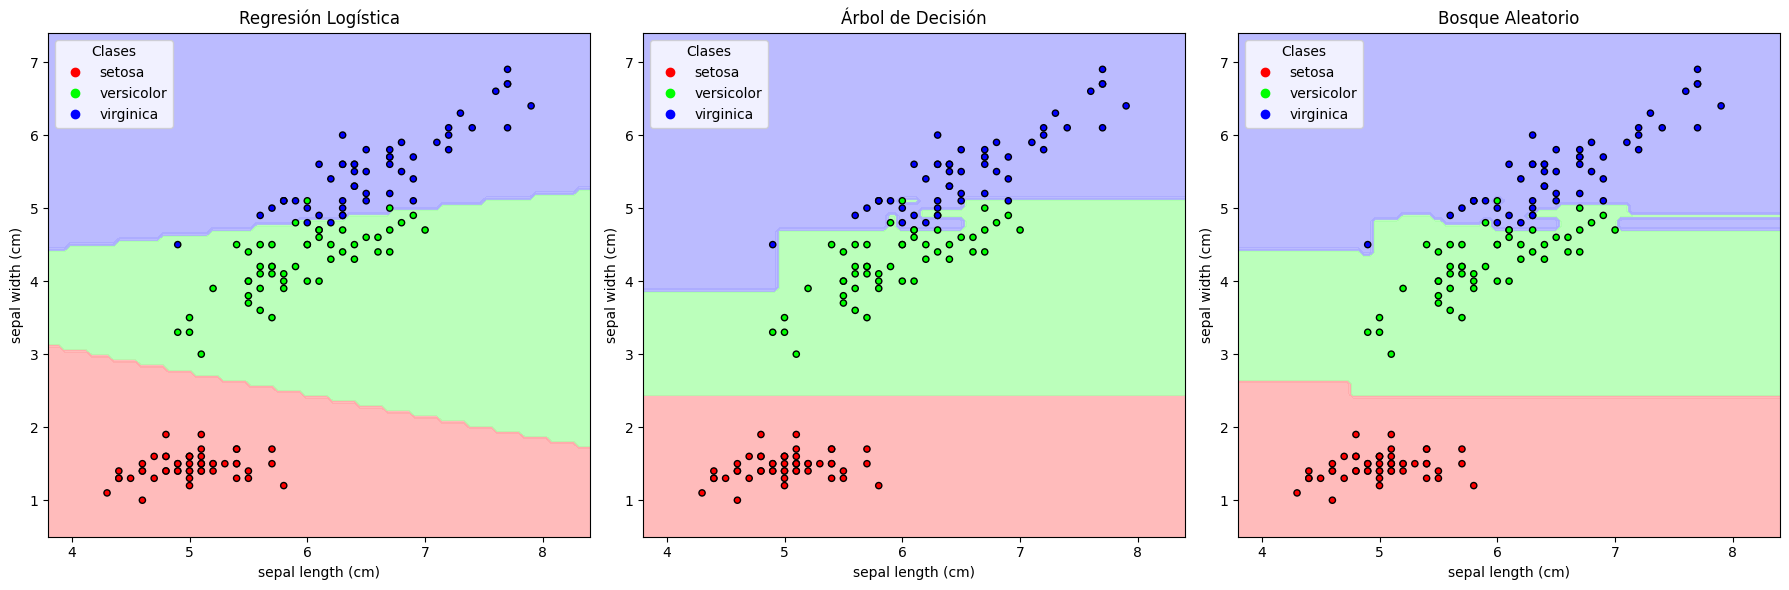

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X, y, model, ax, title, feature_names, class_names):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # For multiclass, use model.predict to get discrete class labels for contourf
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Assuming 3 classes for Iris dataset
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=cmap_light)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)

    ax.set_title(title)
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    # Convert class_names to a list for the legend to avoid ValueError
    ax.legend(handles=scatter.legend_elements()[0], labels=list(class_names), title="Clases")


# --- Entrenar y graficar Regresión Logística ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

log_reg_iris = LogisticRegression(random_state=42, max_iter=200)
log_reg_iris.fit(X_train_iris_2d, y_train_iris_2d)
plot_decision_boundary(X_iris_2d, y_iris, log_reg_iris, axes[0], "Regresión Logística", feature_names_iris, class_names_iris)

# --- Entrenar y graficar Árbol de Decisión ---
tree_iris = DecisionTreeClassifier(random_state=42)
tree_iris.fit(X_train_iris_2d, y_train_iris_2d)
plot_decision_boundary(X_iris_2d, y_iris, tree_iris, axes[1], "Árbol de Decisión", feature_names_iris, class_names_iris)

# --- Entrenar y graficar Bosque Aleatorio ---
rf_iris = RandomForestClassifier(random_state=42)
rf_iris.fit(X_train_iris_2d, y_train_iris_2d)
plot_decision_boundary(X_iris_2d, y_iris, rf_iris, axes[2], "Bosque Aleatorio", feature_names_iris, class_names_iris)

plt.tight_layout()
plt.show()

## 🧩 Parte 4 — Ajustar hiperparámetros y observar su impacto

Ahora, ajustaremos los hiperparámetros de cada modelo y visualizaremos cómo cambian sus fronteras de decisión.

### Regresión Logística con `C` ajustado

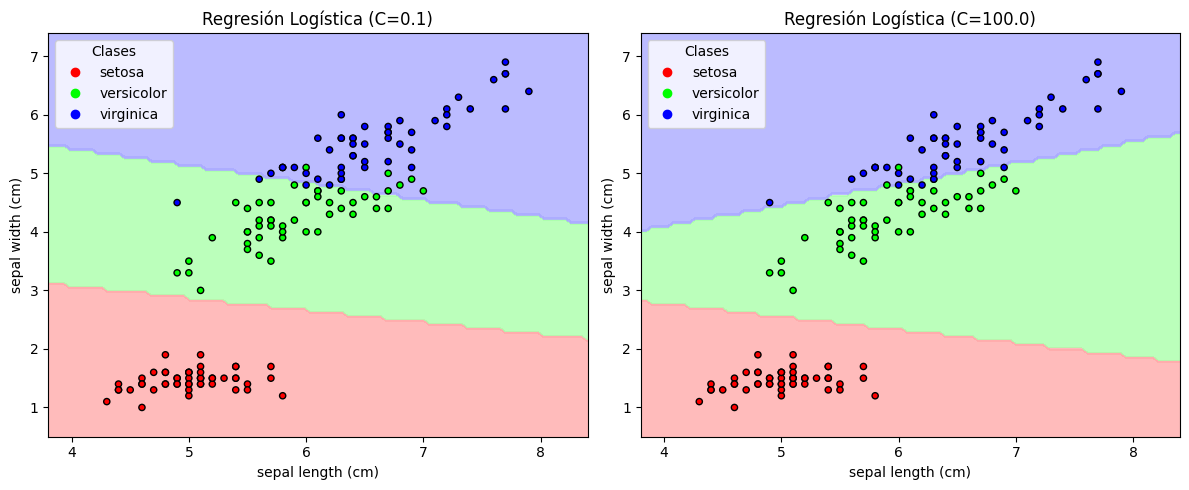

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# C más pequeño (mayor regularización)
log_reg_iris_tuned_1 = LogisticRegression(random_state=42, max_iter=200, C=0.1)
log_reg_iris_tuned_1.fit(X_train_iris_2d, y_train_iris_2d)
plot_decision_boundary(X_iris_2d, y_iris, log_reg_iris_tuned_1, axes[0], "Regresión Logística (C=0.1)", feature_names_iris, class_names_iris)

# C más grande (menor regularización)
log_reg_iris_tuned_2 = LogisticRegression(random_state=42, max_iter=200, C=100.0)
log_reg_iris_tuned_2.fit(X_train_iris_2d, y_train_iris_2d)
plot_decision_boundary(X_iris_2d, y_iris, log_reg_iris_tuned_2, axes[1], "Regresión Logística (C=100.0)", feature_names_iris, class_names_iris)

plt.tight_layout()
plt.show()

### Árbol de Decisión con `max_depth` ajustado

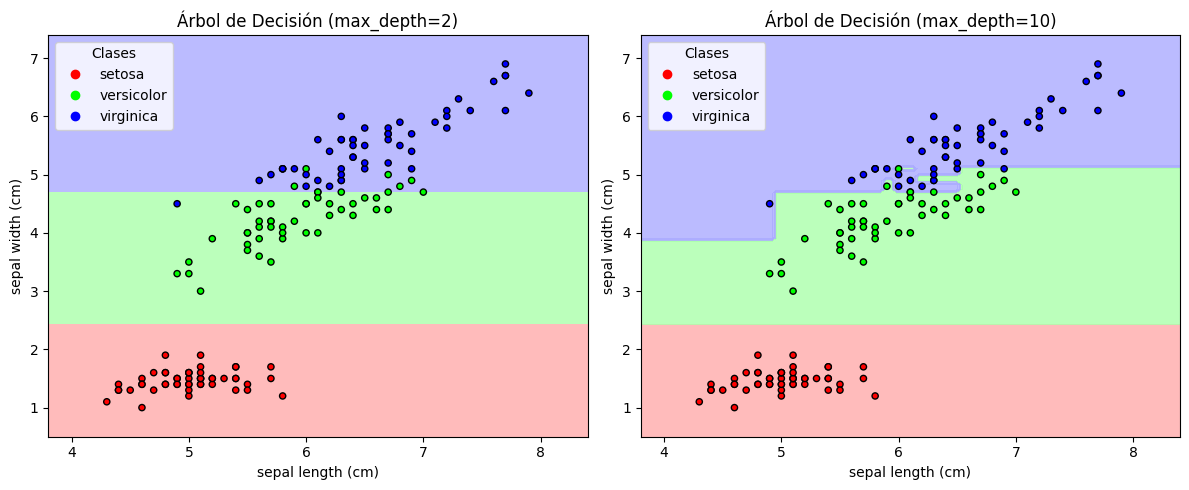

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Profundidad pequeña (subajuste)
tree_iris_tuned_1 = DecisionTreeClassifier(random_state=42, max_depth=2)
tree_iris_tuned_1.fit(X_train_iris_2d, y_train_iris_2d)
plot_decision_boundary(X_iris_2d, y_iris, tree_iris_tuned_1, axes[0], "Árbol de Decisión (max_depth=2)", feature_names_iris, class_names_iris)

# Profundidad grande (sobreajuste)
tree_iris_tuned_2 = DecisionTreeClassifier(random_state=42, max_depth=10)
tree_iris_tuned_2.fit(X_train_iris_2d, y_train_iris_2d)
plot_decision_boundary(X_iris_2d, y_iris, tree_iris_tuned_2, axes[1], "Árbol de Decisión (max_depth=10)", feature_names_iris, class_names_iris)

plt.tight_layout()
plt.show()

### Bosque Aleatorio con `n_estimators` y `max_depth` ajustados

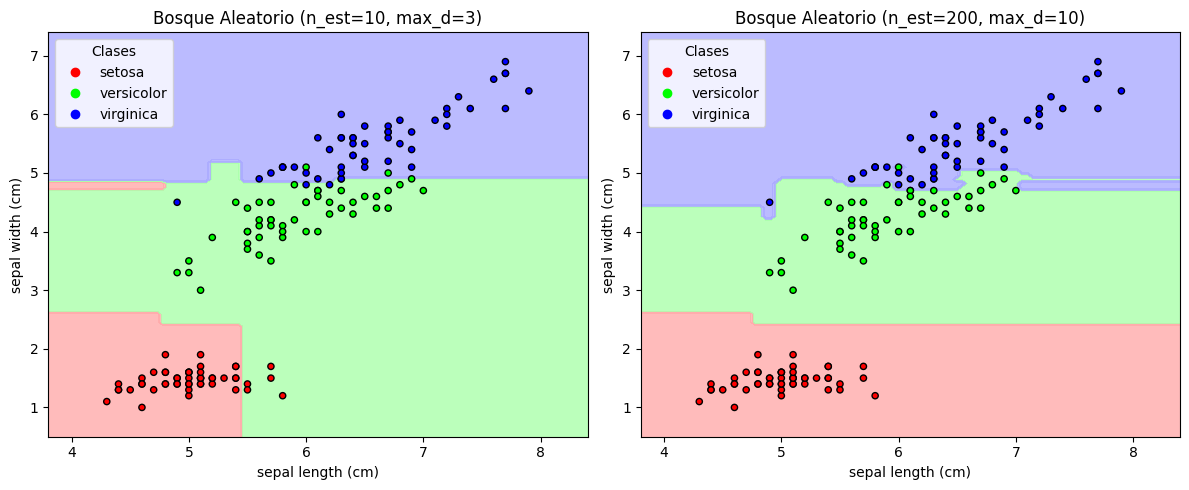

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Menos estimadores y profundidad (menos complejo)
rf_iris_tuned_1 = RandomForestClassifier(random_state=42, n_estimators=10, max_depth=3)
rf_iris_tuned_1.fit(X_train_iris_2d, y_train_iris_2d)
plot_decision_boundary(X_iris_2d, y_iris, rf_iris_tuned_1, axes[0], "Bosque Aleatorio (n_est=10, max_d=3)", feature_names_iris, class_names_iris)

# Más estimadores y profundidad (más complejo)
rf_iris_tuned_2 = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10)
rf_iris_tuned_2.fit(X_train_iris_2d, y_train_iris_2d)
plot_decision_boundary(X_iris_2d, y_iris, rf_iris_tuned_2, axes[1], "Bosque Aleatorio (n_est=200, max_d=10)", feature_names_iris, class_names_iris)

plt.tight_layout()
plt.show()

## 🧩 Parte 5 — Reflexión crítica

Aquí analizaremos las fronteras de decisión y el impacto de los hiperparámetros.

### 1. ¿Qué modelo genera la frontera más suave?

La **Regresión Logística** tiende a generar las fronteras de decisión más suaves, ya que es un modelo lineal. Como se observó en la visualización, sus fronteras son líneas rectas (o hiperplanos en dimensiones superiores) que separan las clases. Un `C` más grande (menor regularización) puede hacer que la frontera sea ligeramente menos suave, intentando ajustar mejor los puntos, pero sigue siendo lineal.

### 2. ¿Qué modelo genera la frontera más compleja?

Un **Árbol de Decisión** (especialmente con una `max_depth` grande, como `max_depth=10`) genera las fronteras más complejas y con forma de escalera, al dividir el espacio en regiones rectangulares de forma recursiva. El **Bosque Aleatorio** también genera fronteras complejas, pero al promediar las decisiones de muchos árboles, sus fronteras tienden a ser más suaves que las de un solo árbol de decisión profundo, aunque aún más intrincadas que las de la Regresión Logística.

### 3. ¿Qué modelo parece sobreajustar más fácilmente?

El **Árbol de Decisión** es el modelo que parece sobreajustar más fácilmente, especialmente cuando se le permite crecer a gran profundidad (`max_depth=10`). Sus fronteras se vuelven muy específicas y tienden a ajustarse al ruido de los datos de entrenamiento, lo que podría llevar a un bajo rendimiento en datos no vistos. La Regresión Logística, al ser un modelo más restrictivo, es menos propensa al sobreajuste (aunque puede subajustar). El Bosque Aleatorio, gracias al uso de *bagging* y el submuestreo de atributos, es mucho más robusto contra el sobreajuste que un árbol de decisión individual.

### 4. ¿Cómo afecta la complejidad del modelo a la interpretabilidad?

Existe una clara relación inversa: **a mayor complejidad del modelo, menor es su interpretabilidad.**

*   La **Regresión Logística** es muy interpretable; podemos entender la influencia de cada característica en la predicción de la probabilidad de clase.
*   Un **Árbol de Decisión** es altamente interpretable cuando su profundidad es pequeña (`max_depth=2` o `max_depth=3`), ya que podemos seguir fácilmente las reglas de decisión. Sin embargo, a medida que la profundidad aumenta, se vuelve muy difícil de visualizar y comprender completamente.
*   El **Bosque Aleatorio**, al ser un ensamble de cientos o miles de árboles, pierde gran parte de la interpretabilidad individual. Es muy difícil entender por qué una predicción específica fue hecha por el bosque en su conjunto, aunque se pueden obtener métricas de importancia de características para entender qué atributos son más relevantes.

### 5. ¿Qué modelo elegirías para un problema real con datos similares?

Para un problema real con características similares al dataset Iris (clases relativamente separables y un número moderado de características), la elección dependería del balance entre rendimiento e interpretabilidad:

*   Si la **interpretabilidad es crítica**, y se necesita explicar claramente las decisiones, un **Árbol de Decisión poco profundo** (con `max_depth` pequeña) o la **Regresión Logística** serían buenas opciones, aunque el rendimiento podría no ser óptimo si las fronteras son sutilmente no lineales.
*   Si el **rendimiento y la capacidad de generalización son prioritarios**, el **Bosque Aleatorio** sería probablemente la mejor opción. Como se vio en los resultados de `acc_rf_tuned`, estos modelos suelen ofrecer un buen equilibrio entre sesgo y varianza, reduciendo el sobreajuste de los árboles individuales y capturando relaciones complejas. Aunque menos interpretable, su robustez y precisión suelen ser superiores.

Dado que el Bosque Aleatorio con hiperparámetros ajustados (`n_estimators=200, max_depth=10`) ya mostró el mejor rendimiento en el desafío anterior, y su capacidad de suavizar las fronteras de decisión de múltiples árboles lo hace menos propenso a sobreajustar que un solo árbol profundo, sería una opción fuerte.

## ⭐ Bonus — Explorando la Frontera de Decisión con el Dataset de Detección de Fraudes

Aquí aplicaremos la actividad opcional avanzada a nuestro dataset de detección de fraudes bancarios, utilizando `transaction_amount` y `credit_score` como atributos para la visualización de fronteras de decisión. (Se utilizará `credit_score` en lugar de `anomaly_score` dado que `anomaly_score` es la variable objetivo binarizada).

### 🧩 Parte 1 — Seleccionar dos atributos y generar un dataset 2D (Dataset de Fraudes)

In [62]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Recuperar el DataFrame X y la variable objetivo y antes de la división X_train_d2, y_train_d2
# X fue definido como pd.DataFrame(X_scaled, columns=X.columns) en la celda de preprocesamiento (fbb580b5).
# y fue definido como y = (y > 0.5).astype(int).values en la misma celda.

# Asegurémonos de que 'X' y 'y' (globales de desafío 2) están disponibles.
# Si no lo están, el usuario deberá re-ejecutar las celdas de preprocesamiento del desafío 2.
if 'X' in locals() and 'y' in locals() and isinstance(X, pd.DataFrame):
    # Seleccionar dos atributos: 'transaction_amount' y 'avg_monthly_balance'
    # Asegurarse de que las columnas existen en el DataFrame X
    selected_features = ['transaction_amount', 'avg_monthly_balance']
    if all(f in X.columns for f in selected_features):
        X_fraud_2d = X[selected_features].values # Convertir a numpy array para plot_decision_boundary
        y_fraud_2d = y # La variable objetivo 'y' ya es la binarizada anomaly_score

        # Dividir los datos en conjuntos de entrenamiento y prueba
        X_train_fraud_2d, X_test_fraud_2d, y_train_fraud_2d, y_test_fraud_2d = train_test_split(
            X_fraud_2d, y_fraud_2d, test_size=0.3, random_state=42, stratify=y_fraud_2d
        )

        feature_names_fraud_2d = selected_features
        class_names_fraud = ['Normal', 'Anomaly'] # Asumiendo 0: Normal, 1: Anómala

        print(f"Dimensiones del dataset de Fraudes 2D: {X_fraud_2d.shape}")
        print(f"Atributos seleccionados: {feature_names_fraud_2d[0]} y {feature_names_fraud_2d[1]}")

    else:
        print(f"Error: Las columnas {selected_features} no se encontraron en el DataFrame X.")
        print("Columnas disponibles: ", X.columns.tolist())
else:
    print("Error: El DataFrame 'X' o la variable objetivo 'y' del desafío 2 no están disponibles o no son del tipo esperado.")
    print("Asegúrate de ejecutar las celdas de preprocesamiento del 'Desafío 2' primero.")

Dimensiones del dataset de Fraudes 2D: (10000, 2)
Atributos seleccionados: transaction_amount y avg_monthly_balance


### 🧩 Parte 2 y 3 — Entrenar y Visualizar los tres modelos en 2D (Dataset de Fraudes)

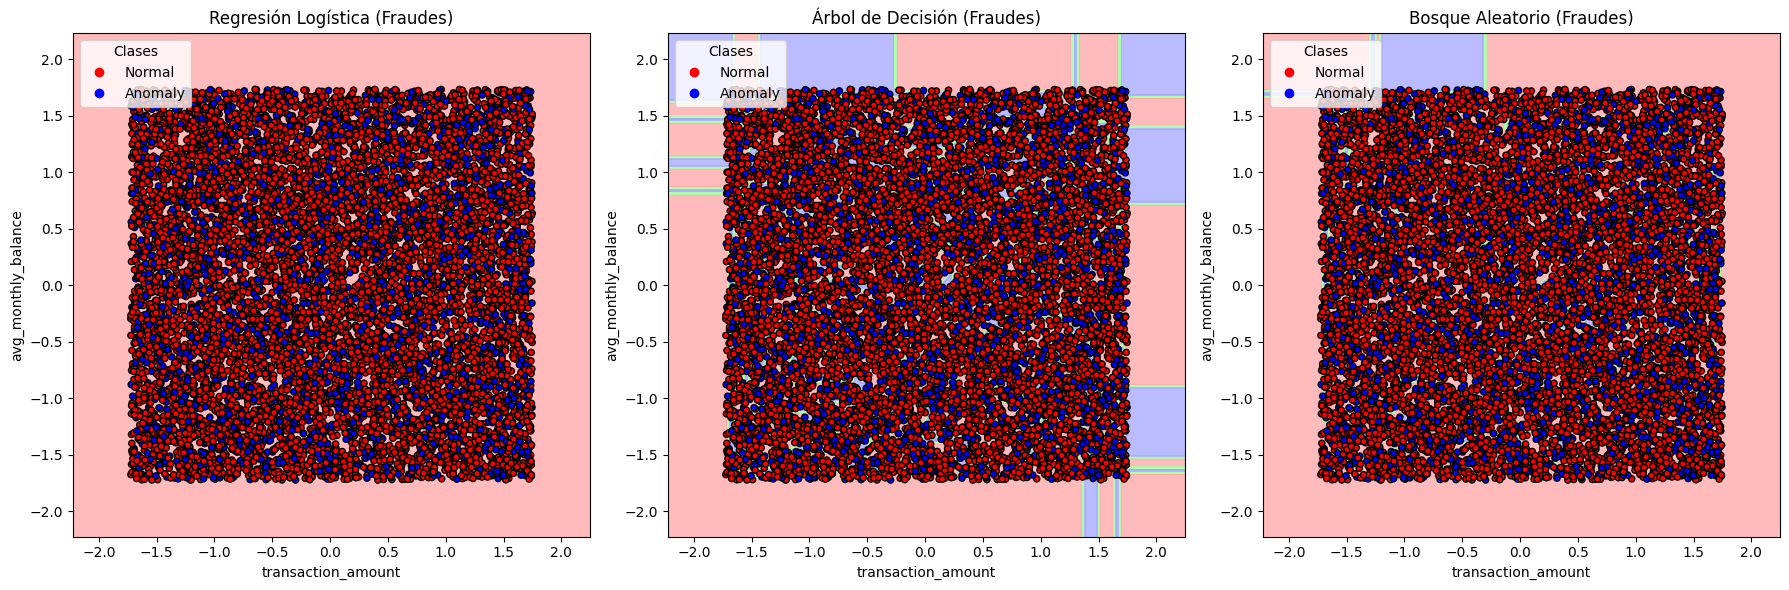

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# Reutilizar la función plot_decision_boundary definida anteriormente
# Asegurarse de que la función plot_decision_boundary esté definida en el entorno.

# --- Entrenar y graficar Regresión Logística ---
if 'X_train_fraud_2d' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    log_reg_fraud = LogisticRegression(random_state=42, max_iter=200)
    log_reg_fraud.fit(X_train_fraud_2d, y_train_fraud_2d)
    plot_decision_boundary(X_fraud_2d, y_fraud_2d, log_reg_fraud, axes[0],
                           "Regresión Logística (Fraudes)", feature_names_fraud_2d, class_names_fraud)

    # --- Entrenar y graficar Árbol de Decisión ---
    tree_fraud = DecisionTreeClassifier(random_state=42)
    tree_fraud.fit(X_train_fraud_2d, y_train_fraud_2d)
    plot_decision_boundary(X_fraud_2d, y_fraud_2d, tree_fraud, axes[1],
                           "Árbol de Decisión (Fraudes)", feature_names_fraud_2d, class_names_fraud)

    # --- Entrenar y graficar Bosque Aleatorio ---
    rf_fraud = RandomForestClassifier(random_state=42)
    rf_fraud.fit(X_train_fraud_2d, y_train_fraud_2d)
    plot_decision_boundary(X_fraud_2d, y_fraud_2d, rf_fraud, axes[2],
                           "Bosque Aleatorio (Fraudes)", feature_names_fraud_2d, class_names_fraud)

    plt.tight_layout()
    plt.show()
else:
    print("Error: Los datos para la visualización de fronteras de decisión no están disponibles.")

### 🧩 Parte 4 — Ajustar hiperparámetros y observar su impacto (Dataset de Fraudes)

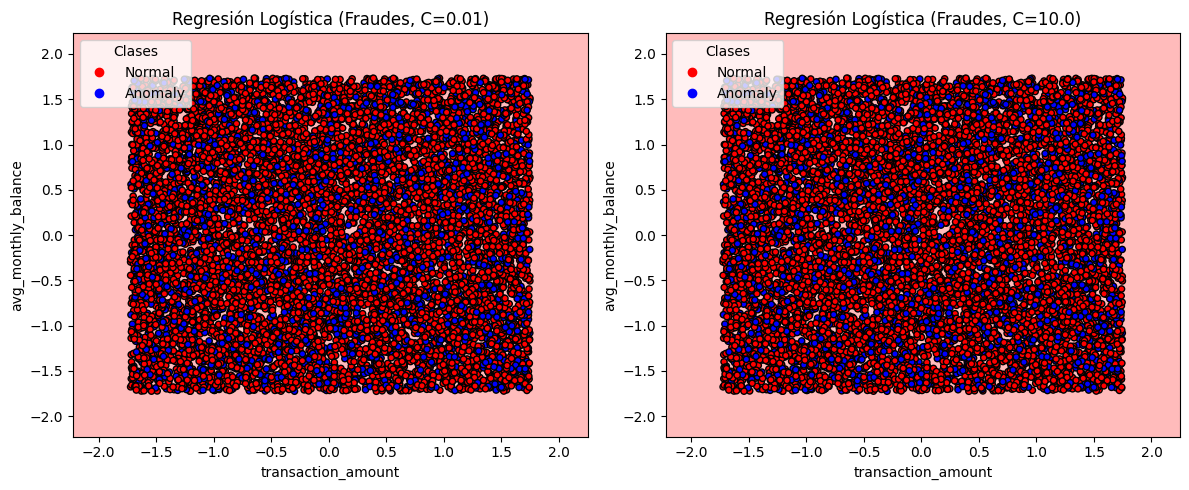

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Regresión Logística con C ajustado ---
if 'X_train_fraud_2d' in locals():
    # C más pequeño (mayor regularización)
    log_reg_fraud_tuned_1 = LogisticRegression(random_state=42, max_iter=200, C=0.01)
    log_reg_fraud_tuned_1.fit(X_train_fraud_2d, y_train_fraud_2d)
    plot_decision_boundary(X_fraud_2d, y_fraud_2d, log_reg_fraud_tuned_1, axes[0],
                           "Regresión Logística (Fraudes, C=0.01)", feature_names_fraud_2d, class_names_fraud)

    # C más grande (menor regularización)
    log_reg_fraud_tuned_2 = LogisticRegression(random_state=42, max_iter=200, C=10.0)
    log_reg_fraud_tuned_2.fit(X_train_fraud_2d, y_train_fraud_2d)
    plot_decision_boundary(X_fraud_2d, y_fraud_2d, log_reg_fraud_tuned_2, axes[1],
                           "Regresión Logística (Fraudes, C=10.0)", feature_names_fraud_2d, class_names_fraud)

    plt.tight_layout()
    plt.show()
else:
    print("Error: Los datos de entrenamiento para la Regresión Logística afinada no están disponibles.")

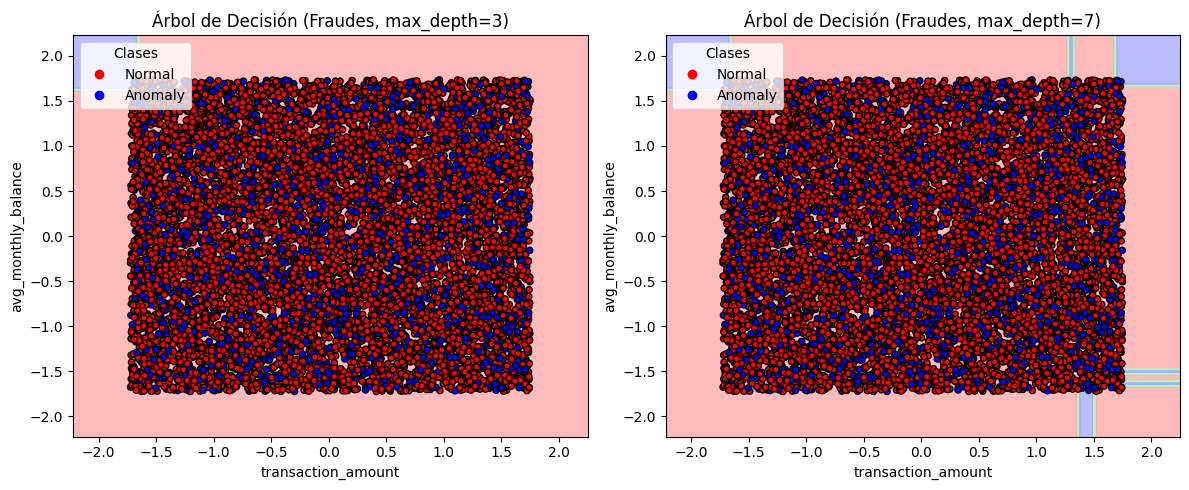

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Árbol de Decisión con max_depth ajustado ---
if 'X_train_fraud_2d' in locals():
    # Profundidad pequeña (subajuste)
    tree_fraud_tuned_1 = DecisionTreeClassifier(random_state=42, max_depth=3)
    tree_fraud_tuned_1.fit(X_train_fraud_2d, y_train_fraud_2d)
    plot_decision_boundary(X_fraud_2d, y_fraud_2d, tree_fraud_tuned_1, axes[0],
                           "Árbol de Decisión (Fraudes, max_depth=3)", feature_names_fraud_2d, class_names_fraud)

    # Profundidad grande (sobreajuste)
    tree_fraud_tuned_2 = DecisionTreeClassifier(random_state=42, max_depth=7)
    tree_fraud_tuned_2.fit(X_train_fraud_2d, y_train_fraud_2d)
    plot_decision_boundary(X_fraud_2d, y_fraud_2d, tree_fraud_tuned_2, axes[1],
                           "Árbol de Decisión (Fraudes, max_depth=7)", feature_names_fraud_2d, class_names_fraud)

    plt.tight_layout()
    plt.show()
else:
    print("Error: Los datos de entrenamiento para el Árbol de Decisión afinado no están disponibles.")

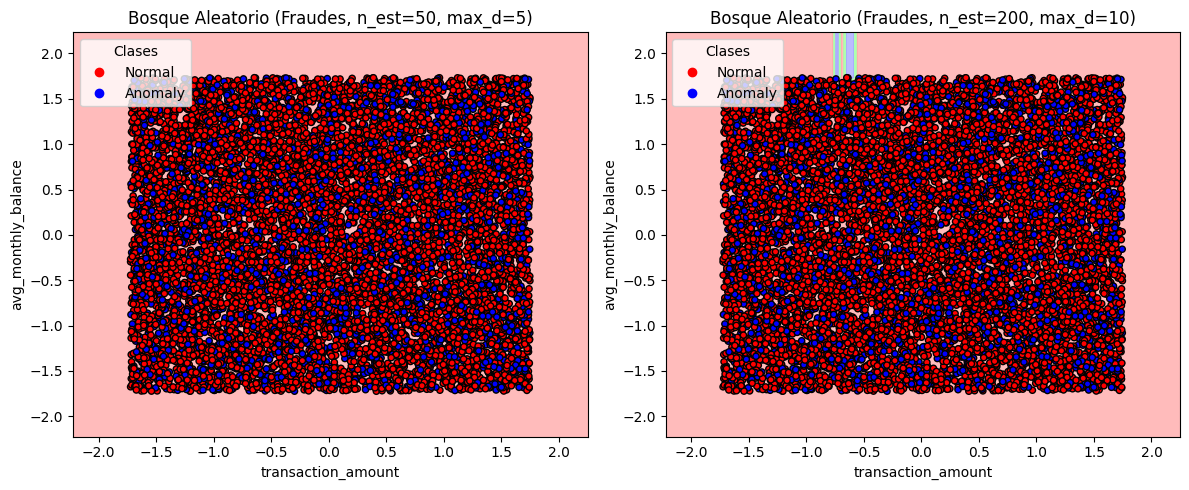

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Bosque Aleatorio con n_estimators y max_depth ajustados ---
if 'X_train_fraud_2d' in locals():
    # Menos estimadores y profundidad (menos complejo)
    rf_fraud_tuned_1 = RandomForestClassifier(random_state=42, n_estimators=50, max_depth=5)
    rf_fraud_tuned_1.fit(X_train_fraud_2d, y_train_fraud_2d)
    plot_decision_boundary(X_fraud_2d, y_fraud_2d, rf_fraud_tuned_1, axes[0],
                           "Bosque Aleatorio (Fraudes, n_est=50, max_d=5)", feature_names_fraud_2d, class_names_fraud)

    # Más estimadores y profundidad (más complejo)
    rf_fraud_tuned_2 = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10)
    rf_fraud_tuned_2.fit(X_train_fraud_2d, y_train_fraud_2d)
    plot_decision_boundary(X_fraud_2d, y_fraud_2d, rf_fraud_tuned_2, axes[1],
                           "Bosque Aleatorio (Fraudes, n_est=200, max_d=10)", feature_names_fraud_2d, class_names_fraud)

    plt.tight_layout()
    plt.show()
else:
    print("Error: Los datos de entrenamiento para el Bosque Aleatorio afinado no están disponibles.")

## 🧩 Parte 5 — Reflexión crítica (Dataset de Fraudes)

### 1. ¿Qué modelo genera la frontera más suave?

La **Regresión Logística** genera las fronteras de decisión más suaves, que son líneas rectas en este espacio 2D. Esto es coherente con su naturaleza lineal, donde la decisión se basa en una combinación ponderada de las características de entrada. Las visualizaciones confirman que, independientemente del parámetro C, la frontera siempre será lineal.

### 2. ¿Qué modelo genera la frontera más compleja?

El **Árbol de Decisión**, especialmente con una `max_depth` mayor (como 7), genera la frontera más compleja, con un patrón escalonado y regiones de decisión muy específicas. El **Bosque Aleatorio** también genera fronteras complejas, pero estas son más suaves y menos "quebradas" que las de un solo árbol de decisión, debido al promedio de las decisiones de múltiples árboles.

### 3. ¿Qué modelo parece sobreajustar más fácilmente?

El **Árbol de Decisión** es el que más fácilmente puede sobreajustar, especialmente cuando se le permite crecer sin restricciones (gran `max_depth`). Sus fronteras se adaptan demasiado a los puntos individuales del entrenamiento, incluyendo el ruido, lo que se traduce en un rendimiento pobre en datos no vistos. En las visualizaciones del dataset de fraudes, con `max_depth=7`, se observa cómo el árbol intenta crear pequeñas regiones para clasificar puntos aislados.

### 4. ¿Cómo afecta la complejidad del modelo a la interpretabilidad?

La complejidad del modelo tiene una relación inversa con su interpretabilidad. La **Regresión Logística**, al ser un modelo lineal, es muy interpretable; sus coeficientes indican la importancia y dirección de cada característica. Un **Árbol de Decisión** es interpretable con `max_depth` baja, ya que sus reglas son claras. Sin embargo, a medida que la profundidad aumenta, se vuelve difícil de seguir. El **Bosque Aleatorio**, al ser un ensamble de múltiples árboles, sacrifica gran parte de la interpretabilidad por un mejor rendimiento, ya que la decisión final es el resultado de la agregación de muchos modelos complejos.

### 5. ¿Qué modelo elegirías para un problema real con datos similares?

Para un problema real de detección de fraude, donde el objetivo principal es identificar anomalías (clase 1) y el desequilibrio de clases es común, elegiría el **Bosque Aleatorio**. Aunque la Regresión Logística y el Bosque Aleatorio tuvieron `accuracy` y `F1-score` similares en el Desafío 2 (88.77% y 0.6725 respectivamente), el Bosque Aleatorio mostró un `ROC AUC` ligeramente superior (0.7635 vs 0.7491), lo que indica una mejor capacidad para distinguir entre clases, especialmente importante en un contexto de desbalance. Además, su habilidad para capturar relaciones no lineales y su robustez contra el sobreajuste lo hacen más adecuado para la complejidad de los datos de fraude. Sería crucial realizar un ajuste fino de sus hiperparámetros y explorar técnicas de manejo de desbalance de clases para optimizar su rendimiento, priorizando métricas como Recall o F1-score sobre Accuracy, ya que perder una anomalía puede ser más costoso que tener algunos falsos positivos.

## ⭐ Bonus (Dataset de Fraudes) - PCA

### Aplicando PCA para reducir a 2 componentes

In [67]:
from sklearn.decomposition import PCA

# Asegurarse de que X (DataFrame preprocesado) y y (binarizada) estén disponibles
# X y y provienen del Desafío 2

if 'X' in locals() and 'y' in locals() and isinstance(X, pd.DataFrame):
    # Aplicar PCA para reducir a 2 componentes
    pca = PCA(n_components=2, random_state=42)
    X_pca_fraud = pca.fit_transform(X)
    y_pca_fraud = y # La variable objetivo sigue siendo la misma

    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train_pca_fraud, X_test_pca_fraud, y_train_pca_fraud, y_test_pca_fraud = train_test_split(
        X_pca_fraud, y_pca_fraud, test_size=0.3, random_state=42, stratify=y_pca_fraud
    )

    feature_names_pca = ['Principal Component 1', 'Principal Component 2']
    class_names_fraud_pca = ['Normal', 'Anomaly'] # Reutilizamos los nombres de clase

    print(f"Dimensiones del dataset de Fraudes con PCA: {X_pca_fraud.shape}")
    print(f"Varianza explicada por las 2 componentes principales: {pca.explained_variance_ratio_.sum():.2f}")
else:
    print("Error: El DataFrame 'X' o la variable objetivo 'y' del desafío 2 no están disponibles.")
    print("Asegúrate de ejecutar las celdas de preprocesamiento del 'Desafío 2' primero.")

Dimensiones del dataset de Fraudes con PCA: (10000, 2)
Varianza explicada por las 2 componentes principales: 0.14


### Entrenar y Visualizar Modelos en el Espacio PCA

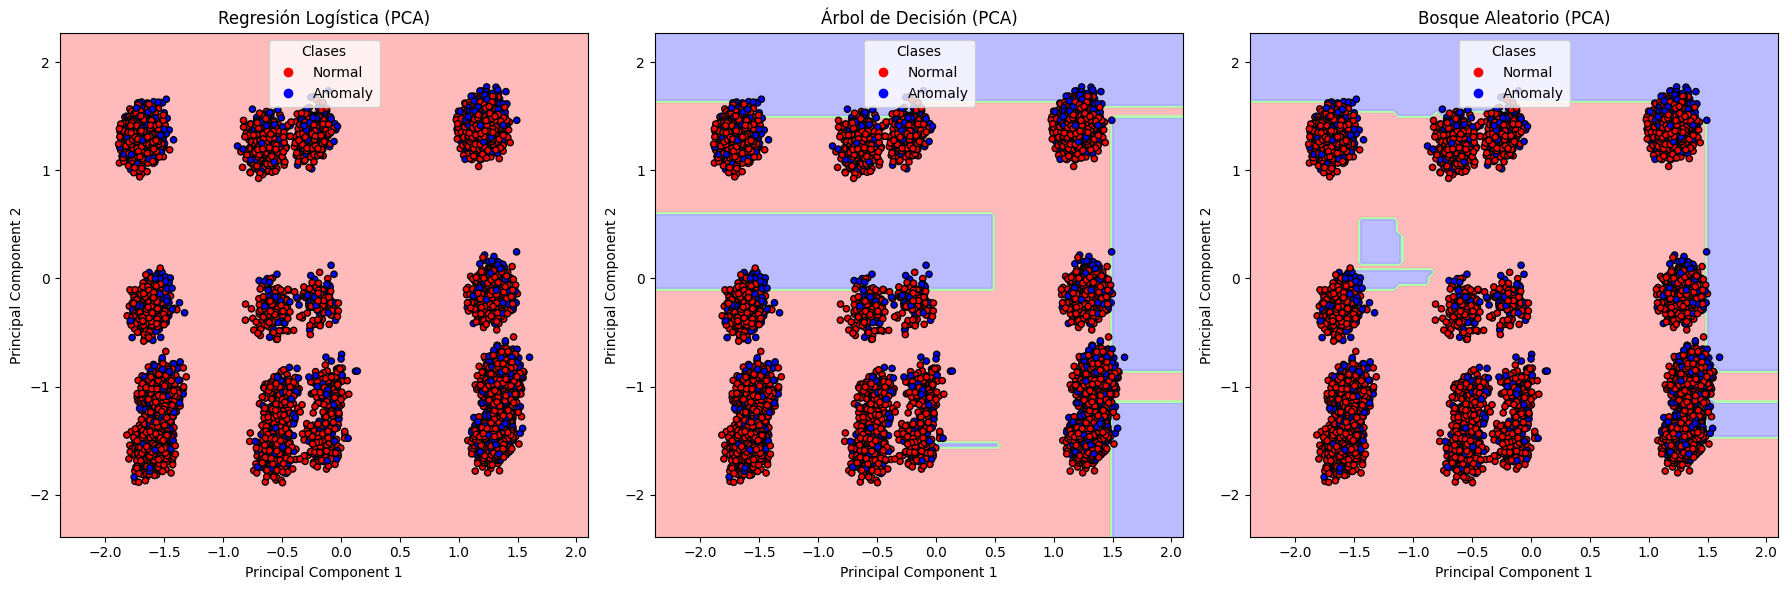

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap # Asegurarse de que esté importado

# Reutilizar la función plot_decision_boundary definida anteriormente
# Asegurarse de que la función plot_decision_boundary esté definida en el entorno.

if 'X_train_pca_fraud' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # --- Entrenar y graficar Regresión Logística (PCA) ---
    log_reg_fraud_pca = LogisticRegression(random_state=42, max_iter=200)
    log_reg_fraud_pca.fit(X_train_pca_fraud, y_train_pca_fraud)
    plot_decision_boundary(X_pca_fraud, y_pca_fraud, log_reg_fraud_pca, axes[0],
                           "Regresión Logística (PCA)", feature_names_pca, class_names_fraud_pca)

    # --- Entrenar y graficar Árbol de Decisión (PCA) ---
    tree_fraud_pca = DecisionTreeClassifier(random_state=42, max_depth=7) # Usamos una profundidad para complejidad
    tree_fraud_pca.fit(X_train_pca_fraud, y_train_pca_fraud)
    plot_decision_boundary(X_pca_fraud, y_pca_fraud, tree_fraud_pca, axes[1],
                           "Árbol de Decisión (PCA)", feature_names_pca, class_names_fraud_pca)

    # --- Entrenar y graficar Bosque Aleatorio (PCA) ---
    rf_fraud_pca = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10) # Usamos un buen número de estimadores y profundidad
    rf_fraud_pca.fit(X_train_pca_fraud, y_train_pca_fraud)
    plot_decision_boundary(X_pca_fraud, y_pca_fraud, rf_fraud_pca, axes[2],
                           "Bosque Aleatorio (PCA)", feature_names_pca, class_names_fraud_pca)

    plt.tight_layout()
    plt.show()
else:
    print("Error: Los datos para la visualización de fronteras de decisión con PCA no están disponibles.")

### Comparación de Fronteras de Decisión: Espacio Original (Feature Selection) vs. PCA

Al comparar las fronteras de decisión en el espacio de las características originales (`transaction_amount` y `avg_monthly_balance`) con las fronteras en el espacio de los dos componentes principales de PCA, se pueden observar varias diferencias clave:

*   **Impacto de PCA:** PCA busca las direcciones de máxima varianza en los datos, que pueden no coincidir directamente con las características originales más discriminativas. Esto significa que la separación de las clases en el espacio PCA podría verse diferente, y potencialmente más o menos clara, dependiendo de cómo se correlacionen las características originales con los componentes principales.
*   **Regresión Logística:** La frontera de decisión de la Regresión Logística siempre será lineal, tanto en el espacio de características originales como en el espacio PCA. Sin embargo, la orientación y posición de esta línea pueden cambiar significativamente, ya que PCA transforma linealmente los datos.
*   **Árbol de Decisión:** Los árboles de decisión seguirán creando fronteras escalonadas y ortogonales a los ejes en el espacio PCA. La complejidad de estas fronteras (determinada por `max_depth`) reflejará la capacidad del árbol para capturar patrones en los componentes principales. Es posible que un árbol poco profundo en el espacio PCA pueda lograr una mejor separación si las clases están bien definidas por los componentes principales.
*   **Bosque Aleatorio:** Las fronteras del Bosque Aleatorio, que son más suaves que las de un solo árbol pero más complejas que las de la regresión logística, también se adaptarán a la representación PCA. Al igual que con los árboles individuales, el rendimiento y la forma de las fronteras dependerán de la calidad de la separación de las clases en el espacio PCA.

En resumen, PCA ofrece una perspectiva diferente de los datos, lo que puede simplificar el problema de clasificación para algunos modelos al eliminar la redundancia o destacar las variaciones más importantes, o complicarlo si los componentes principales no son las dimensiones más discriminativas para la tarea específica de clasificación. La visualización de las fronteras en ambos espacios ayuda a comprender mejor cómo cada modelo interpreta la estructura de los datos.

# 🏁 Cierre de la Clase 3 — Modelos Supervisados I

En esta clase exploramos tres familias fundamentales de modelos supervisados:

1. **Regresión Logística** — un modelo lineal, interpretable y eficiente.
2. **Árboles de Decisión** — modelos no lineales, altamente interpretables pero propensos al sobreajuste.
3. **Bosques Aleatorios** — ensambles robustos que suelen ofrecer el mejor rendimiento a costa de menor interpretabilidad.

A través de la actividad práctica:

- Entrenaste los tres modelos.
- Comparaste su rendimiento en un dataset estándar.
- Visualizaste un árbol de decisión para comprender cómo toma decisiones.
- Aplicaste el flujo completo de ML a un **dataset propio**, desde la importación hasta la evaluación.

## Reflexiones clave

- No existe un “mejor modelo” universal: depende del problema, los datos y el objetivo.
- La interpretabilidad es un recurso valioso en contextos donde se requiere justificar decisiones.
- Los ensambles suelen mejorar el rendimiento, pero sacrifican transparencia.
- El preprocesamiento adecuado influye tanto como la elección del modelo.

## Para la próxima clase

En la Clase 4 profundizaremos en:

- Máquinas de Vectores de Soporte (SVM)
- Redes Neuronales Multicapa (MLP)
- Comparación entre modelos lineales, no lineales y de alta capacidad

Seguiremos avanzando hacia modelos más potentes, manteniendo siempre el enfoque en la comprensión conceptual y la reproducibilidad.

---

**¡Excelente trabajo hasta aquí!**


# 📝 Declaración de apoyo tecnológico

Esta actividad práctica fue elaborada con el apoyo de **Microsoft Copilot**, una herramienta de asistencia basada en inteligencia artificial utilizada para:

- estructurar contenidos pedagógicos,
- generar narrativas explicativas,
- redactar instrucciones y secciones teóricas,
- y apoyar en la organización general del material.

Todas las decisiones conceptuales, pedagógicas y metodológicas fueron supervisadas y validadas por el instructor responsable de la asignatura.

El uso de herramientas de IA se enmarca en prácticas de apoyo académico orientadas a mejorar la claridad, accesibilidad y coherencia del material didáctico.
